ALGORITHMIC PERSUASION ANALYSIS
Full pipeline with nested feature selection (FULLY CORRECTED)

Settings:
  Outer CV splits: 5
  Inner CV splits: 3
  Top-k grid: [5, 10, 15, 20, None]
  Random seed: 0

PERSON 1: Pre-visibility Prediction

Person 1 Feature Report (Pre-Visibility Only)
Total features: 17
Categorical: 3 -> ['content_type', 'post_format', 'verified']
- categorical: 3
   ['content_type', 'post_format', 'verified']
- time: 3
   ['post_hour', 'post_dow', 'post_month']
- authority: 3
   ['authority_log', 'account_age_years', 'follower_count']
- early: 8
   ['early_likes', 'early_comments', 'early_shares', 'early_total_engagement', 'early_engagement_velocity', 'early_comment_share_ratio', 'persuasive_power_index', 'early_window_mins']


[Person 1] Running nested feature selection for model: Ridge
Fold 1: selected=5 features | RMSE=0.6112 | R2=0.4945
Fold 2: selected=5 features | RMSE=0.6058 | R2=0.4767
Fold 3: selected=5 features | RMSE=0.6000 | R2=0.4984
Fold 4: selected=5 feat

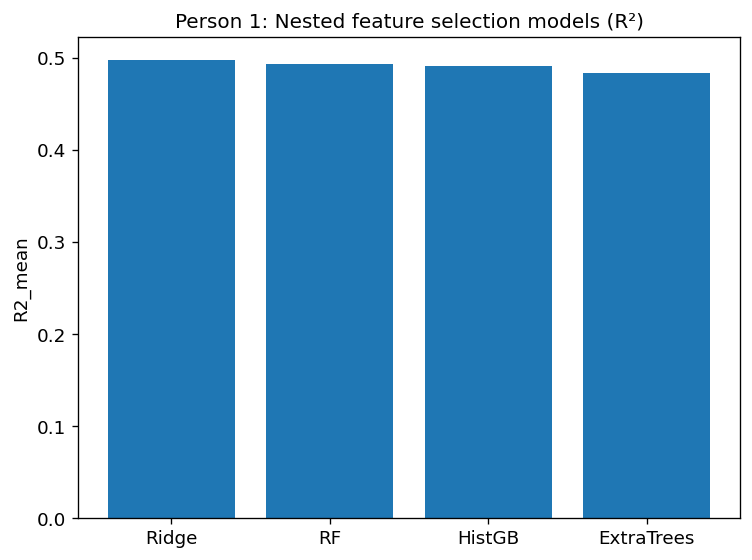

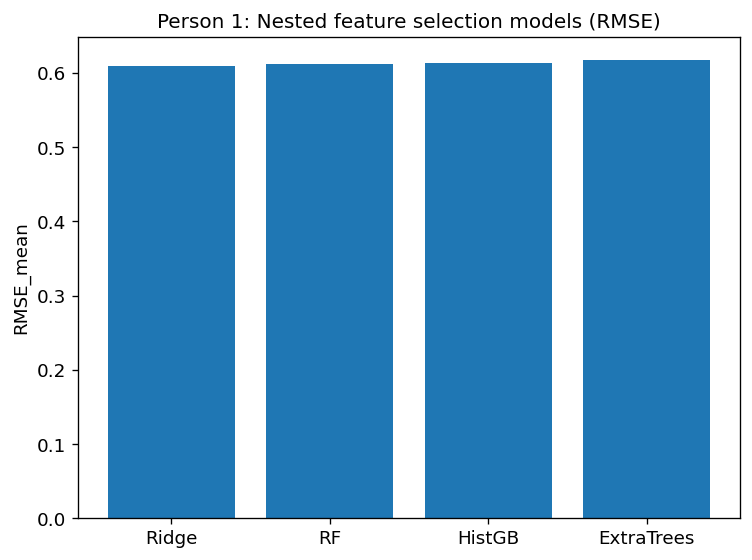

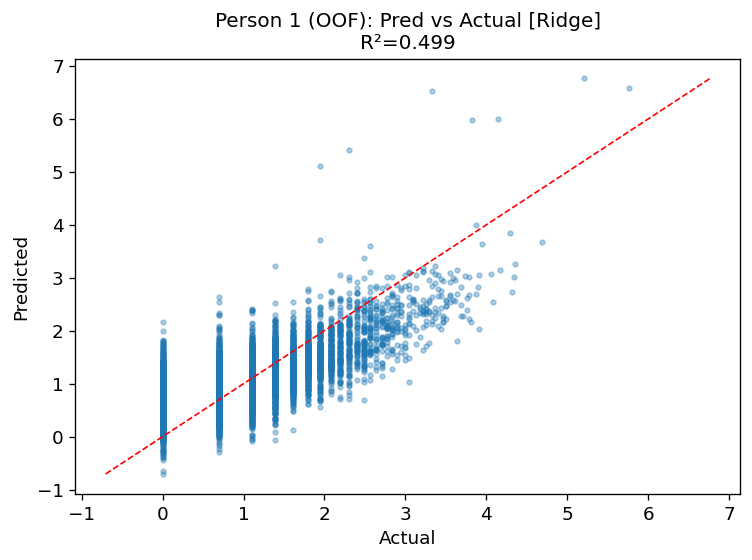

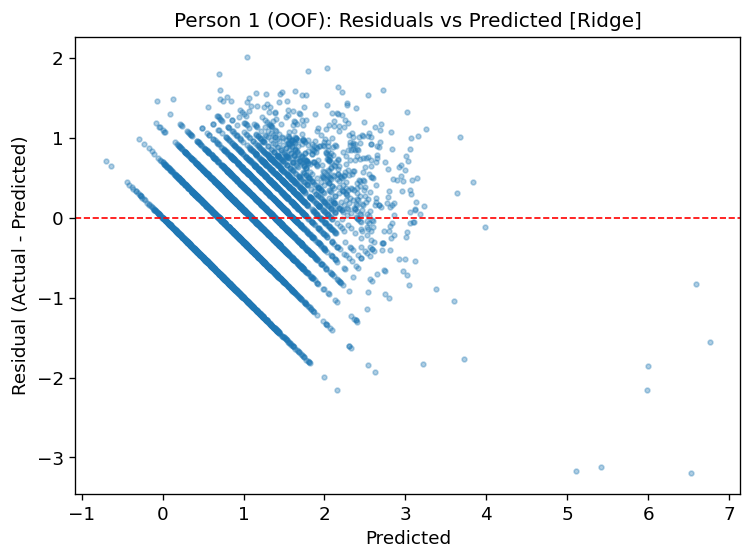

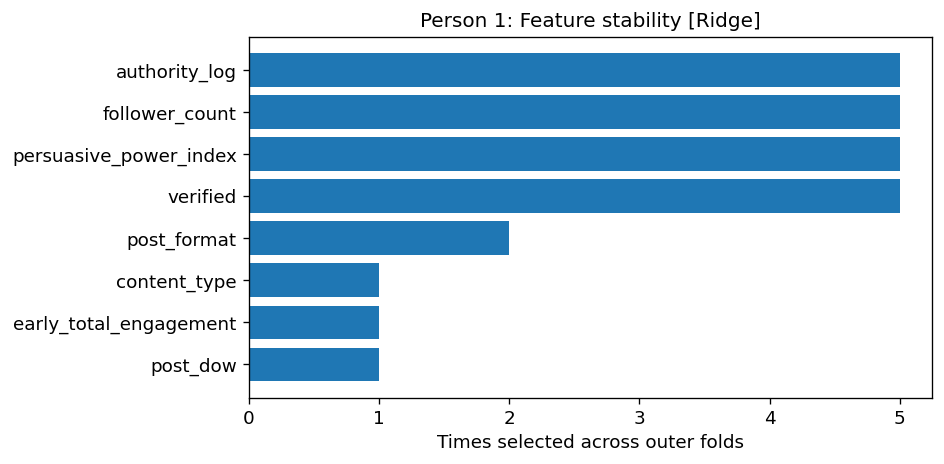

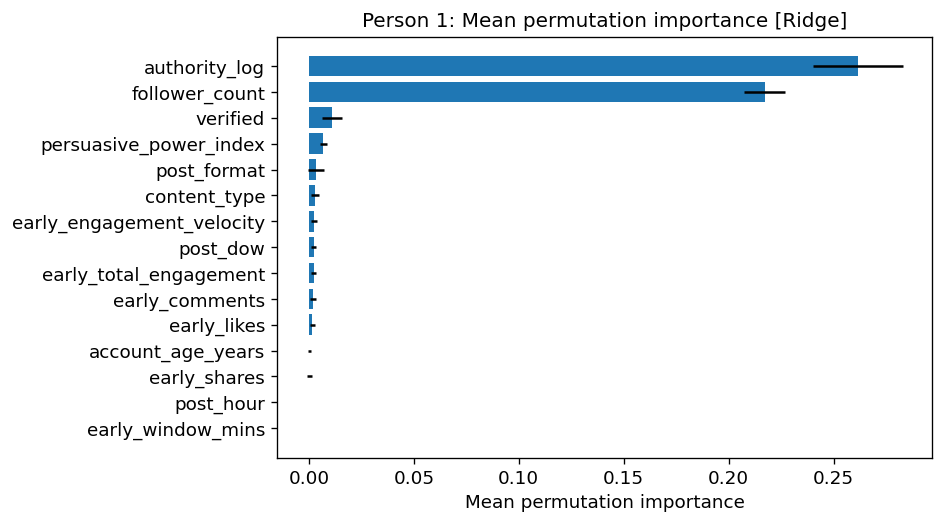

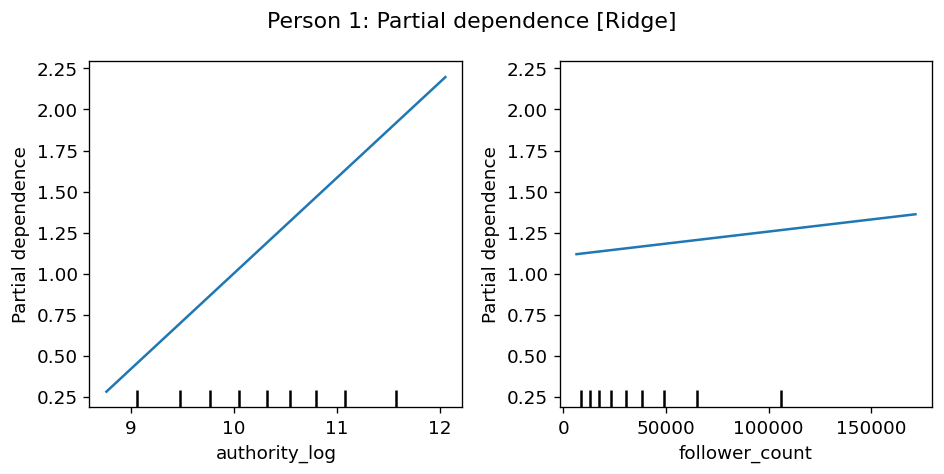


Person 1 Results Table:
            MAE_mean   MAE_std  RMSE_mean  RMSE_std   R2_mean    R2_std
model                                                                  
Ridge       0.489695  0.007705   0.609891  0.011892  0.498266  0.015542
RF          0.495548  0.006468   0.612601  0.008966  0.493549  0.020115
HistGB      0.496101  0.007315   0.613939  0.007209  0.491177  0.022858
ExtraTrees  0.500939  0.006427   0.618093  0.006882  0.484128  0.025789

PERSON 2: Pre vs Amp vs Combined

Person 2 Feature Report: Pre-only
Total features: 17
Categorical: 3 -> ['content_type', 'post_format', 'verified']
- categorical: 3
   ['content_type', 'post_format', 'verified']
- time: 3
   ['post_hour', 'post_dow', 'post_month']
- authority: 3
   ['authority_log', 'account_age_years', 'follower_count']
- early: 8
   ['early_likes', 'early_comments', 'early_shares', 'early_total_engagement', 'early_engagement_velocity', 'early_comment_share_ratio', 'persuasive_power_index', 'early_window_mins']


Pers

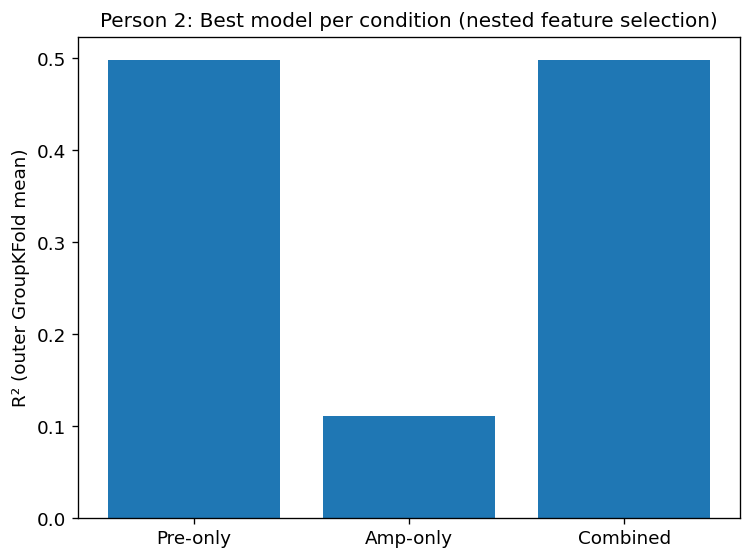

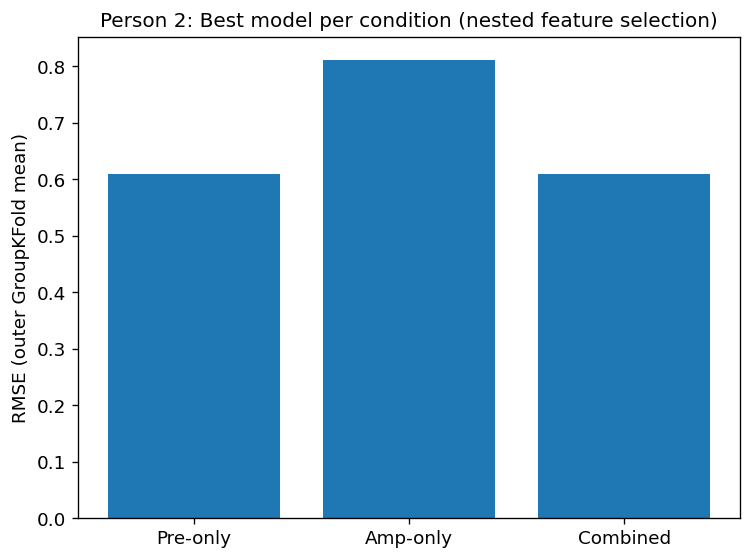

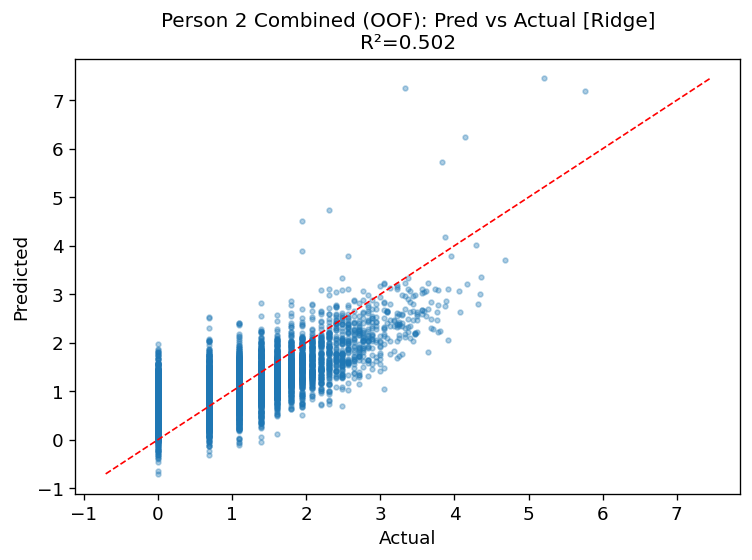

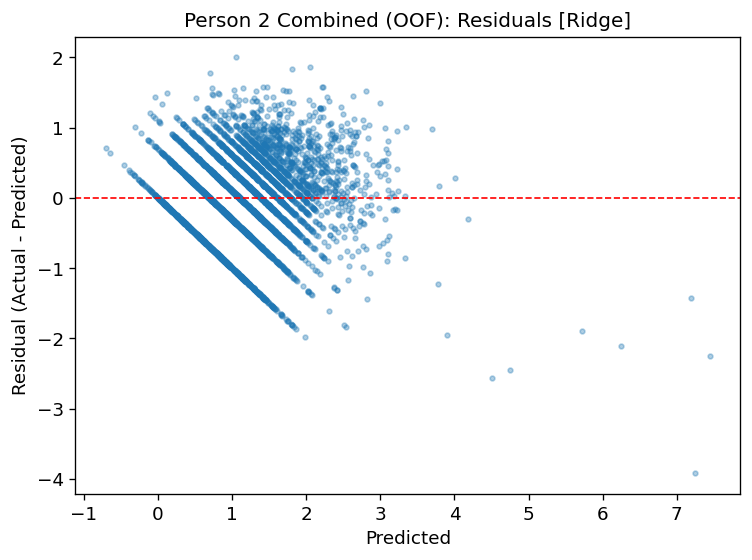

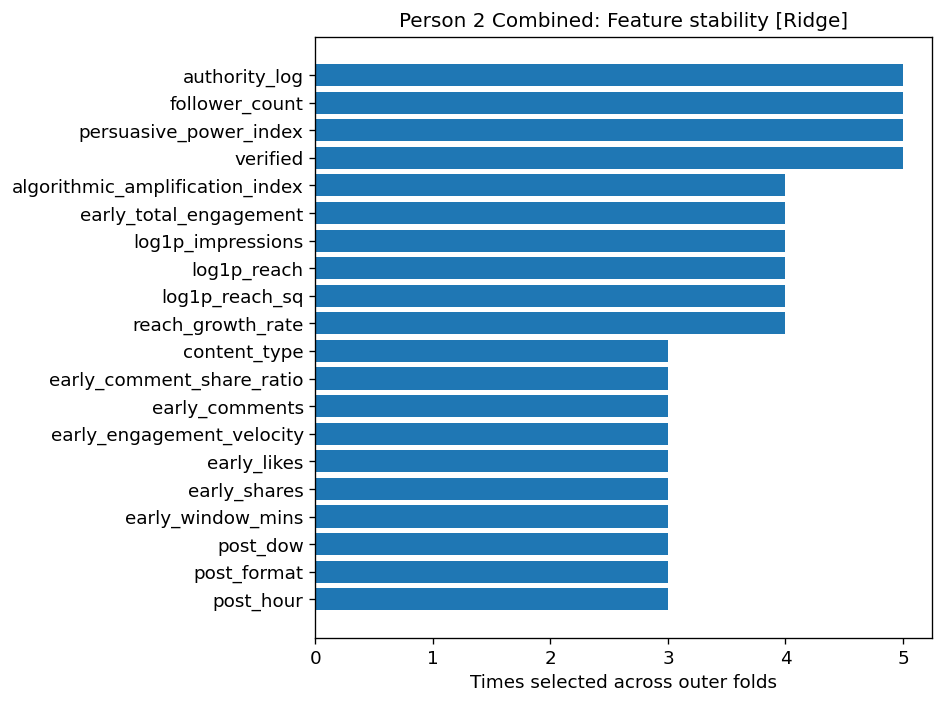

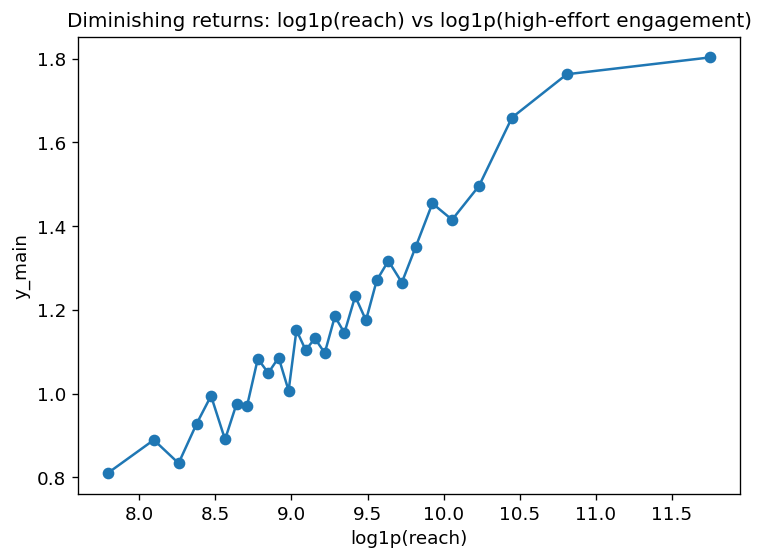

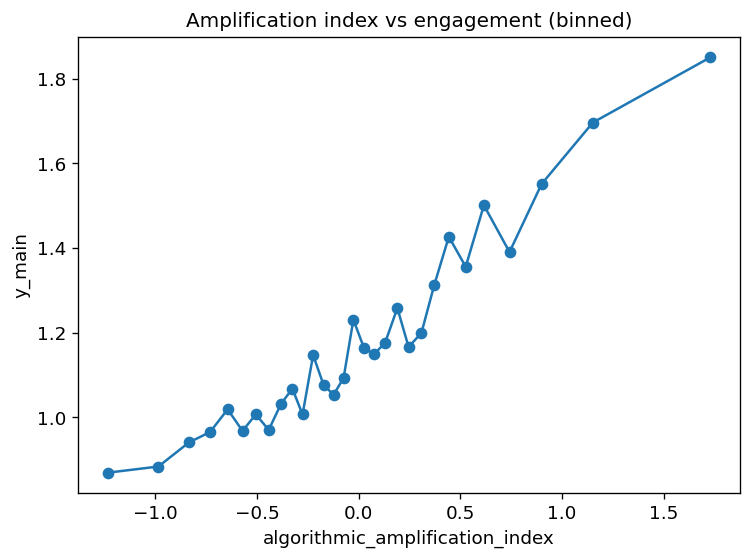


Person 2 Best-Model Comparison:
          MAE_mean   MAE_std  RMSE_mean  RMSE_std   R2_mean    R2_std  \
Pre-only  0.489695  0.007705   0.609891  0.011892  0.498266  0.015542   
Amp-only  0.651952  0.016024   0.812083  0.025076  0.110807  0.032627   
Combined  0.489451  0.008210   0.609769  0.013347  0.498604  0.012386   

         best_model  
Pre-only      Ridge  
Amp-only      Ridge  
Combined      Ridge  

PERSON 3: Two-Stage Mediation (FULLY CORRECTED)

Person 3 Feature Report (Pre-Visibility)
Total features: 17
Categorical: 3 -> ['content_type', 'post_format', 'verified']
- categorical: 3
   ['content_type', 'post_format', 'verified']
- time: 3
   ['post_hour', 'post_dow', 'post_month']
- authority: 3
   ['authority_log', 'account_age_years', 'follower_count']
- early: 8
   ['early_likes', 'early_comments', 'early_shares', 'early_total_engagement', 'early_engagement_velocity', 'early_comment_share_ratio', 'persuasive_power_index', 'early_window_mins']


[Person 3] Running FULLY 

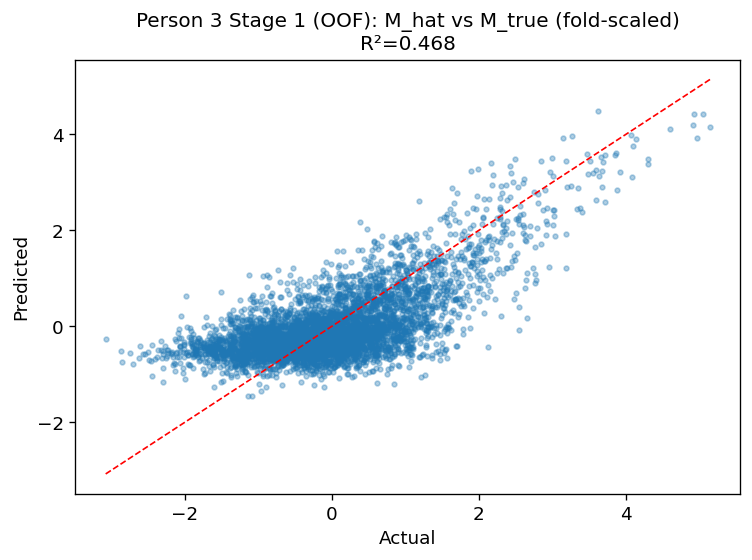

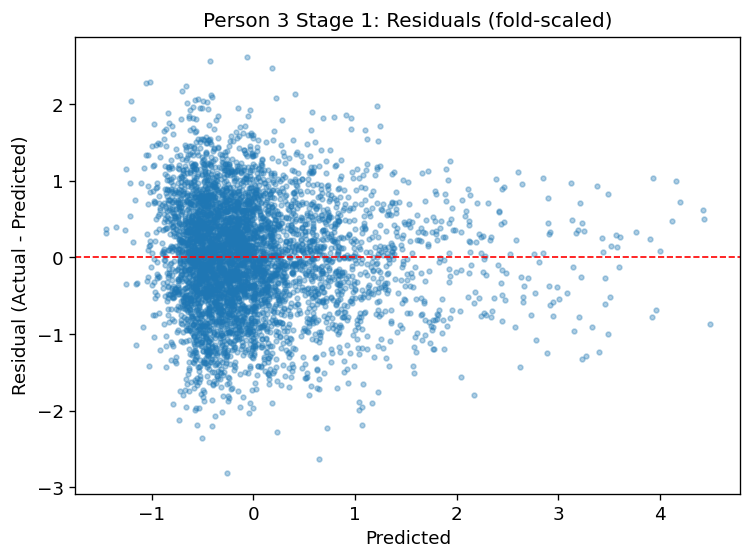

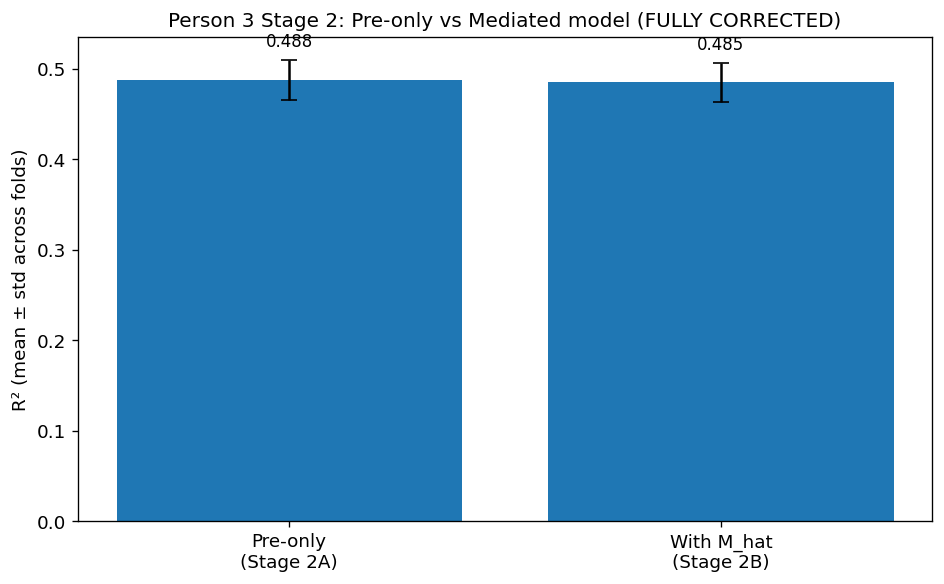

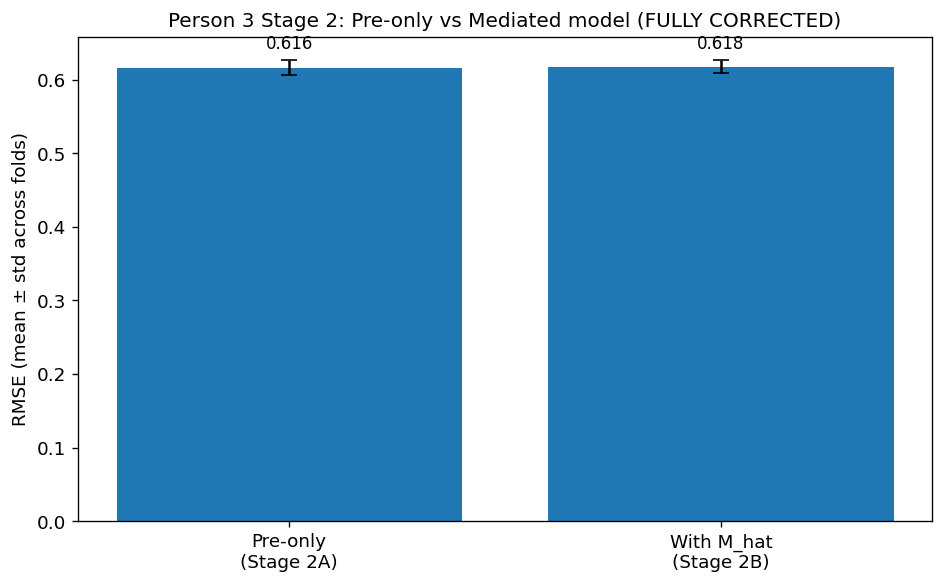

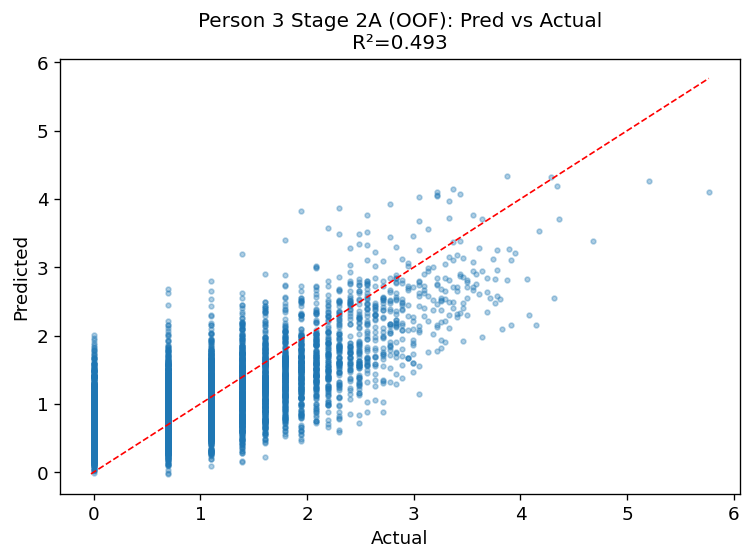

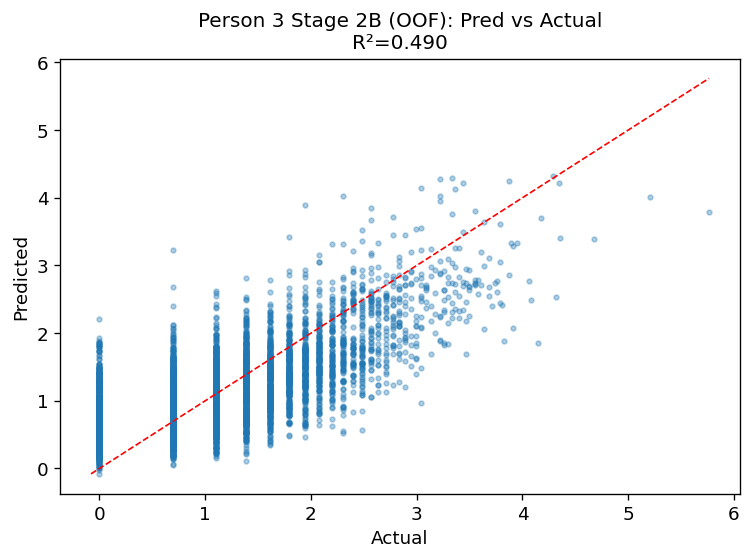

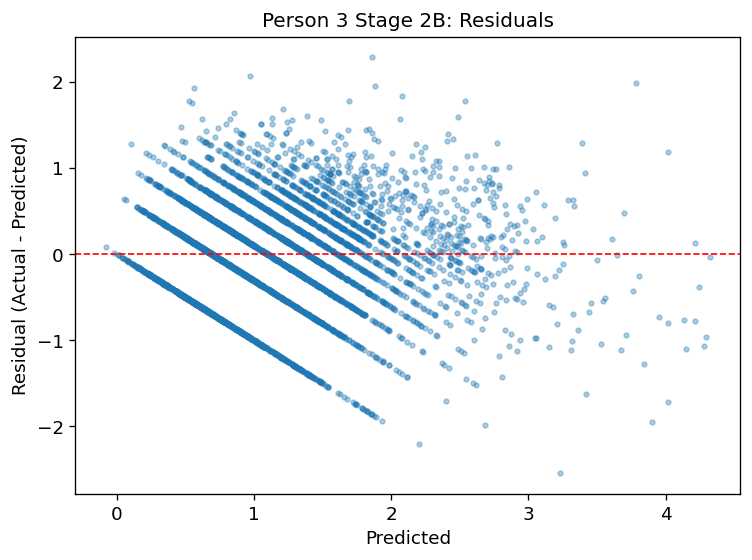

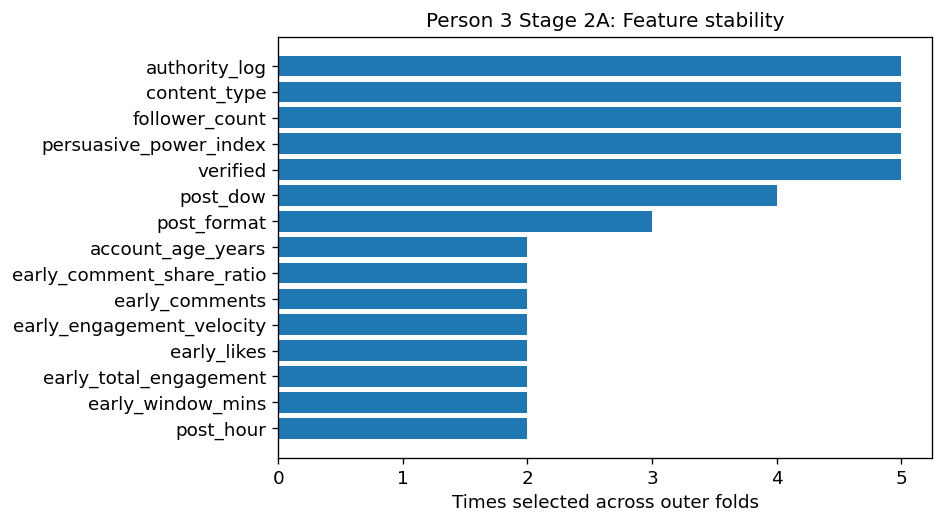

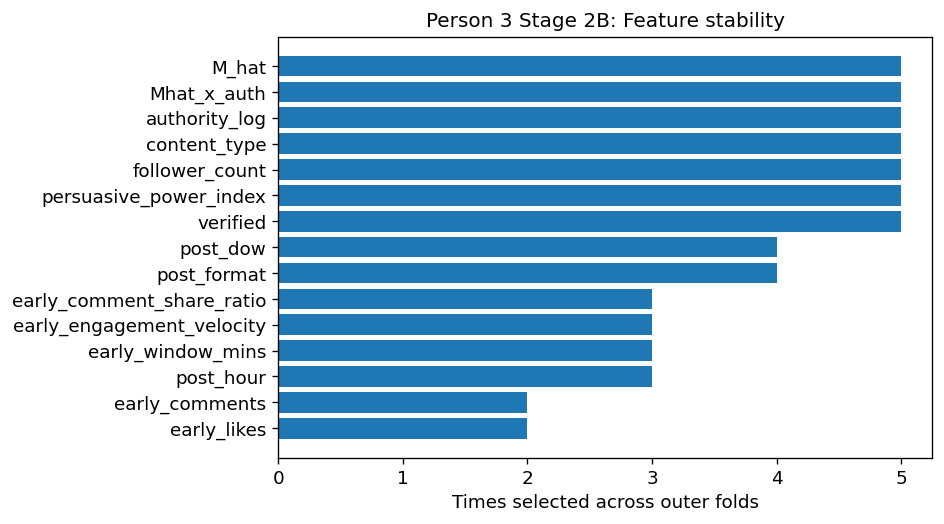

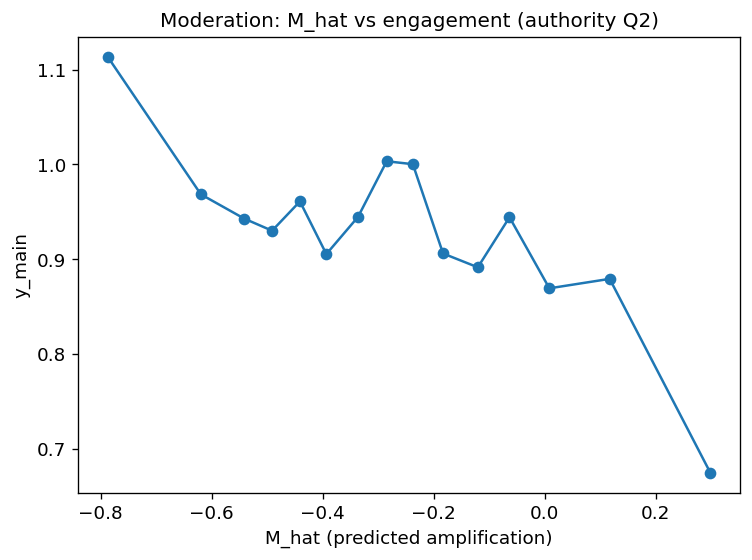

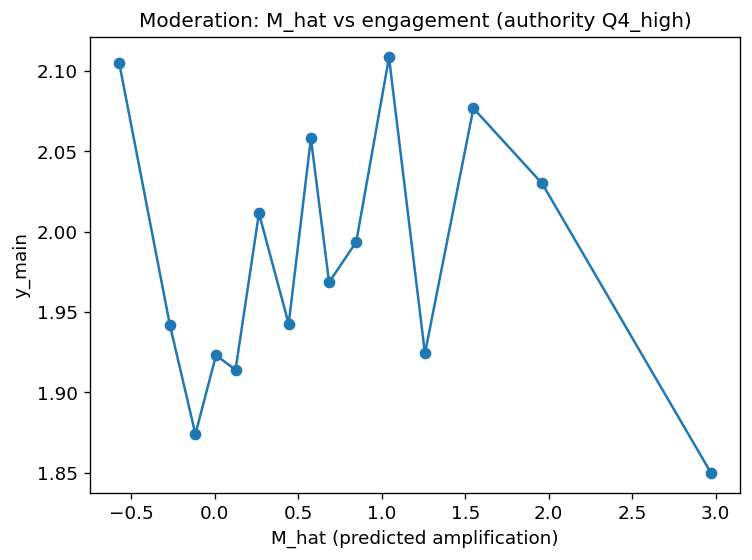

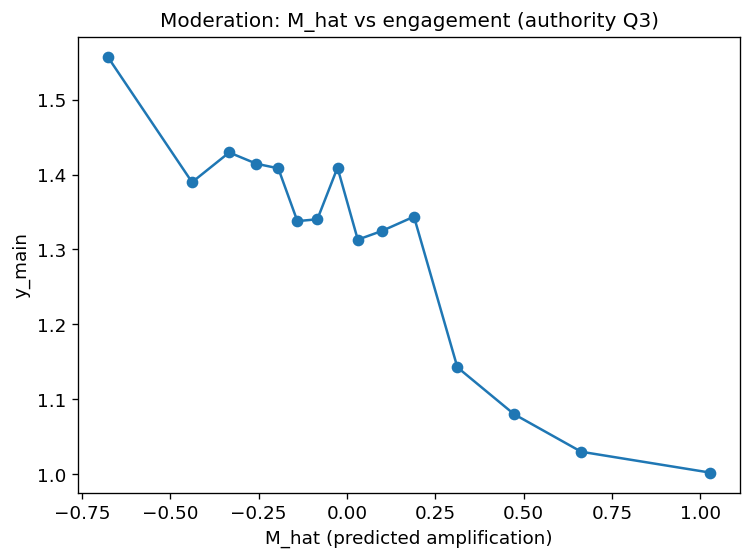

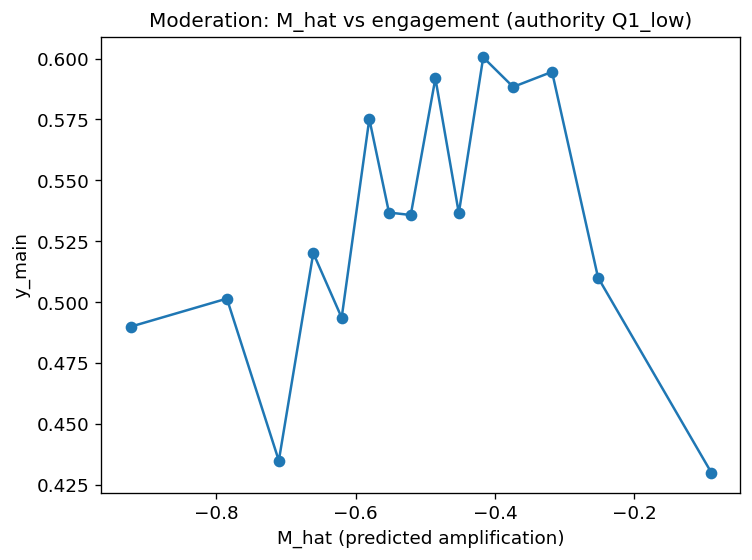


Person 3 Summary (FULLY CORRECTED)

Stage 1 (Mediator Prediction):
  R² = 0.4629 ± 0.0359

Stage 2A (Pre-only with nested FS):
  R² = 0.4879 ± 0.0221
  RMSE = 0.6160 ± 0.0100
  Avg features = 10.0

Stage 2B (With mediator + interaction):
  R² = 0.4853 ± 0.0216
  RMSE = 0.6176 ± 0.0094
  Avg features = 13.2

Improvement from mediator:
  ΔR² = -0.0026
  ΔRMSE = -0.0016 (positive = improvement)

Person 3 Stage 2 Comparison:
                                     MAE_mean   MAE_std  RMSE_mean  RMSE_std  \
condition                                                                      
Pre-only (Stage 2A)                  0.497138  0.007781   0.616001  0.009955   
With M_hat + interaction (Stage 2B)  0.498651  0.006798   0.617567  0.009367   

                                      R2_mean    R2_std  n_features_mean  
condition                                                                 
Pre-only (Stage 2A)                  0.487864  0.022130             10.0  
With M_hat + interaction (St

In [1]:
# ============================================================
# Data:
#   dataset_algorithmic_persuasion_10000.xlsx
#
# Main target:
#   y_main = log1p(high_effort_engagement)
#
# Structure:
#   Person 1: Pre-visibility prediction
#   Person 2: Pre-only vs Amp-only vs Combined
#   Person 3: Two-stage mediator modeling (FULLY CORRECTED)
# ============================================================
# -----------------------------
# 0) GLOBAL SETTINGS
# -----------------------------
import os
import json
import warnings
from collections import Counter, defaultdict
from typing import Dict, List, Tuple, Optional, Any, Union
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
warnings.filterwarnings("ignore")
plt.rcParams["figure.dpi"] = 120
plt.rcParams["savefig.dpi"] = 300
plt.rcParams["font.size"] = 11
plt.rcParams["axes.titlesize"] = 12
plt.rcParams["axes.labelsize"] = 11
DATA_PATH = "dataset_algorithmic_persuasion_10000.xlsx"
FIG_DIR = "/mnt/data/paper_figures"
OUT_DIR = "/mnt/data/project_outputs"
os.makedirs(FIG_DIR, exist_ok=True)
os.makedirs(OUT_DIR, exist_ok=True)
RANDOM_SEED = 0
# Performance/runtime controls
OUTER_SPLITS = 5
INNER_SPLITS = 3
TOP_K_GRID = [5, 10, 15, 20, None]
SCREENING_N_REPEATS = 6
SCREENING_HOLDOUT_FRAC = 0.20
# -----------------------------
# COLUMN NAME CONSTANTS
# -----------------------------
class Columns:
    """Centralized column name definitions to avoid hardcoding throughout."""
    TARGET = "y_main"
    HIGH_EFFORT = "high_effort_engagement"
    LOW_EFFORT = "low_effort_engagement"
    REACH = "reach"
    GROUP = "influencer_id"
    DATETIME = "post_datetime"
    MEDIATOR = "algorithmic_amplification_index"
    AUTHORITY = "authority_log"
    IMPRESSIONS = "impressions"
    VERY_HIGH_REACH = "very_high_reach"
    LOG1P_REACH = "log1p_reach"
    LOG1P_REACH_SQ = "log1p_reach_sq"
    LOG1P_IMPRESSIONS = "log1p_impressions"
    M_TRUE = "M_true"
    M_HAT = "M_hat"
    MHAT_X_AUTH = "Mhat_x_auth"
# -----------------------------
# 1) IMPORTS
# -----------------------------
from sklearn.model_selection import GroupKFold, GroupShuffleSplit
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.inspection import permutation_importance, PartialDependenceDisplay
from sklearn.base import clone, RegressorMixin
from sklearn.linear_model import Ridge
from sklearn.ensemble import (
    HistGradientBoostingRegressor,
    RandomForestRegressor,
    ExtraTreesRegressor
)
# -----------------------------
# 2) I/O + BASIC DATA UTILITIES
# -----------------------------
def load_data(
    excel_path: str,
    data_sheet_candidates: Tuple[str, ...] = ("data", "Data", "Sheet1", "Sheet 1"),
    codebook_sheet_candidates: Tuple[str, ...] = ("codebook", "Codebook", "Sheet2", "Sheet 2")
) -> Tuple[pd.DataFrame, Optional[pd.DataFrame]]:
    """Load data and optional codebook from Excel workbook."""
    xl = pd.ExcelFile(excel_path)
    sheets = xl.sheet_names
    def _read_first_match(candidates):
        for nm in candidates:
            if nm in sheets:
                return pd.read_excel(excel_path, sheet_name=nm)
        return None
    df = _read_first_match(data_sheet_candidates)
    if df is None:
        raise ValueError(
            f"No matching data sheet found among {data_sheet_candidates}. "
            f"Available sheets: {sheets}"
        )
    codebook = _read_first_match(codebook_sheet_candidates)
    return df, codebook
def add_time_features(df: pd.DataFrame, datetime_col: str = None) -> pd.DataFrame:
    """Parse datetime and add time-based predictors."""
    if datetime_col is None:
        datetime_col = Columns.DATETIME
    out = df.copy()
    if datetime_col not in out.columns:
        return out
    out[datetime_col] = pd.to_datetime(out[datetime_col], errors="coerce")
    out["post_hour"] = out[datetime_col].dt.hour
    out["post_dow"] = out[datetime_col].dt.dayofweek
    out["post_month"] = out[datetime_col].dt.month
    return out
def add_main_target(
    df: pd.DataFrame,
    high_effort_col: str = None,
    target_col: str = None
) -> pd.DataFrame:
    """Main prediction target: log1p(high_effort_engagement)."""
    if high_effort_col is None:
        high_effort_col = Columns.HIGH_EFFORT
    if target_col is None:
        target_col = Columns.TARGET
    out = df.copy()
    if high_effort_col not in out.columns:
        raise ValueError(f"Expected column '{high_effort_col}' not found.")
    out[target_col] = np.log1p(out[high_effort_col].clip(lower=0))
    return out
def ensure_tail_flag(
    df: pd.DataFrame,
    reach_col: str = None,
    flag_col: str = None,
    q: float = 0.95
) -> pd.DataFrame:
    """Create a tail indicator for very high reach if not already present."""
    if reach_col is None:
        reach_col = Columns.REACH
    if flag_col is None:
        flag_col = Columns.VERY_HIGH_REACH
    out = df.copy()
    if flag_col not in out.columns:
        if reach_col not in out.columns:
            raise ValueError(f"Need '{reach_col}' to create '{flag_col}'.")
        thresh = out[reach_col].quantile(q)
        out[flag_col] = (out[reach_col] >= thresh).astype(int)
    return out
def add_person2_amplification_features(df: pd.DataFrame) -> pd.DataFrame:
    """Add nonlinear amplification features for Person 2."""
    out = df.copy()
    reach_col = Columns.REACH
    if reach_col not in out.columns:
        raise ValueError(f"Need '{reach_col}' column for amplification features.")
    out[Columns.LOG1P_REACH] = np.log1p(out[reach_col].clip(lower=0))
    out[Columns.LOG1P_REACH_SQ] = out[Columns.LOG1P_REACH] ** 2
    if Columns.IMPRESSIONS in out.columns:
        out[Columns.LOG1P_IMPRESSIONS] = np.log1p(out[Columns.IMPRESSIONS].clip(lower=0))
    out = ensure_tail_flag(out, reach_col=reach_col, flag_col=Columns.VERY_HIGH_REACH, q=0.95)
    return out
def zscore_series(s: pd.Series) -> pd.Series:
    """
    Standardize a series to zero mean and unit variance.
    Handles constant series gracefully.
    """
    s = s.astype(float)
    std = s.std(ddof=0)
    if std < 1e-8:
        warnings.warn("zscore_series: constant or near-constant series detected, returning centered values")
        return s - s.mean()
    return (s - s.mean()) / std
def zscore_series_with_params(
    s: pd.Series,
    mean: float = None,
    std: float = None
) -> Tuple[pd.Series, float, float]:
    """
    Standardize a series. If mean/std not provided, compute from data.
    Returns (standardized_series, mean_used, std_used).
    """
    s = s.astype(float)
    if mean is None:
        mean = s.mean()
    if std is None:
        std = s.std(ddof=0)
    if std < 1e-8:
        warnings.warn("zscore_series_with_params: constant or near-constant series")
        return s - mean, mean, std
    return (s - mean) / std, mean, std
# -----------------------------
# 3) LEAKAGE GUARD
# -----------------------------
def leakage_guard(
    features: List[str],
    forbidden_prefixes: Tuple[str, ...] = ("total_",),
    forbidden_exact: Tuple[str, ...] = None
):
    """Prevent obvious outcome leakage."""
    if forbidden_exact is None:
        forbidden_exact = (
            Columns.HIGH_EFFORT,
            Columns.LOW_EFFORT,
            "engagement_success_index",
            Columns.TARGET
        )
    bad = []
    for f in features:
        if f in forbidden_exact:
            bad.append(f)
            continue
        for p in forbidden_prefixes:
            if f.startswith(p):
                bad.append(f)
                break
    if bad:
        raise ValueError(
            "LeakageGuard: Forbidden/post-treatment features detected:\n"
            f"{sorted(set(bad))}\n"
            "Remove these from the feature list."
        )
# -----------------------------
# 4) FEATURE BUILDERS
# -----------------------------
def build_previsibility_features(df: pd.DataFrame) -> Tuple[List[str], List[str], List[Tuple[str, List[str]]]]:
    """
    Candidate pre-visibility / early-stage feature set.
    Returns (all_features, categorical_features, feature_groups)
    """
    categorical = [c for c in ["content_type", "post_format", "verified"] if c in df.columns]
    time_feats = [c for c in ["post_hour", "post_dow", "post_month"] if c in df.columns]
    authority = [c for c in [Columns.AUTHORITY, "account_age_years", "follower_count"] if c in df.columns]
    early = [c for c in [
        "early_likes",
        "early_comments",
        "early_shares",
        "early_total_engagement",
        "early_engagement_velocity",
        "early_comment_share_ratio",
        "persuasive_power_index",
        "early_window_mins"
    ] if c in df.columns]
    feats = categorical + time_feats + authority + early
    leakage_guard(feats)
    groups = [
        ("categorical", categorical),
        ("time", time_feats),
        ("authority", authority),
        ("early", early)
    ]
    return feats, categorical, groups
def build_amplification_features(df: pd.DataFrame) -> Tuple[List[str], List[Tuple[str, List[str]]]]:
    """
    Candidate amplification-related feature set.
    Returns (all_features, feature_groups)
    """
    amp = [c for c in [
        Columns.LOG1P_REACH,
        Columns.LOG1P_REACH_SQ,
        Columns.VERY_HIGH_REACH,
        Columns.MEDIATOR,
        "reach_growth_rate",
        "exposure_persistence_hours",
        Columns.LOG1P_IMPRESSIONS,
        "impressions_per_reach"
    ] if c in df.columns]
    leakage_guard(amp)
    groups = [("amplification", amp)]
    return amp, groups
# -----------------------------
# 5) MODEL REGISTRY
# -----------------------------
def model_registry(seed: int = 0) -> Dict[str, RegressorMixin]:
    """Final models to compare."""
    return {
        "Ridge": Ridge(alpha=1.0, random_state=seed),
        "HistGB": HistGradientBoostingRegressor(
            random_state=seed,
            max_depth=6,
            learning_rate=0.06,
            max_iter=300
        ),
        "RF": RandomForestRegressor(
            n_estimators=400,
            max_depth=None,
            min_samples_leaf=3,
            max_features="sqrt",
            n_jobs=-1,
            random_state=seed
        ),
        "ExtraTrees": ExtraTreesRegressor(
            n_estimators=600,
            max_depth=None,
            min_samples_leaf=2,
            max_features="sqrt",
            n_jobs=-1,
            random_state=seed
        ),
    }
def screening_model(seed: int = 0) -> RegressorMixin:
    """Tree model used for fold-safe feature ranking."""
    return ExtraTreesRegressor(
        n_estimators=300,
        max_depth=None,
        min_samples_leaf=2,
        max_features="sqrt",
        n_jobs=-1,
        random_state=seed
    )
# -----------------------------
# 6) PREPROCESSING
# -----------------------------
def build_preprocessor_linear(
    all_features: List[str],
    categorical_features: List[str]
) -> ColumnTransformer:
    """Build preprocessor for linear models (with scaling)."""
    numeric_features = [c for c in all_features if c not in categorical_features]
    cat_features = [c for c in all_features if c in categorical_features]
    transformers = []
    if numeric_features:
        transformers.append(("num", Pipeline([("scaler", StandardScaler())]), numeric_features))
    if cat_features:
        transformers.append(("cat", OneHotEncoder(handle_unknown="ignore"), cat_features))
    return ColumnTransformer(
        transformers=transformers,
        remainder="drop",
        verbose_feature_names_out=False
    )
def build_preprocessor_tree(
    all_features: List[str],
    categorical_features: List[str]
) -> ColumnTransformer:
    """Build preprocessor for tree models (no scaling needed)."""
    numeric_features = [c for c in all_features if c not in categorical_features]
    cat_features = [c for c in all_features if c in categorical_features]
    transformers = []
    if numeric_features:
        transformers.append(("num", "passthrough", numeric_features))
    if cat_features:
        transformers.append(("cat", OneHotEncoder(handle_unknown="ignore"), cat_features))
    return ColumnTransformer(
        transformers=transformers,
        remainder="drop",
        verbose_feature_names_out=False
    )
def pick_preprocessor(
    model: RegressorMixin,
    all_features: List[str],
    categorical_features: List[str]
) -> ColumnTransformer:
    """Select appropriate preprocessor based on model type."""
    if isinstance(model, Ridge):
        return build_preprocessor_linear(all_features, categorical_features)
    return build_preprocessor_tree(all_features, categorical_features)
# -----------------------------
# 7) METRICS + BASIC ML UTILITIES
# -----------------------------
def prepare_model_frame(
    df: pd.DataFrame,
    features: List[str],
    target: str,
    group_col: str = None
) -> Tuple[pd.DataFrame, pd.Series, pd.Series]:
    """Prepare X, y, groups from dataframe, dropping rows with missing values."""
    if group_col is None:
        group_col = Columns.GROUP
    needed = list(dict.fromkeys(features + [target, group_col]))
    data = df[needed].dropna().reset_index(drop=True)
    X = data[features].copy()
    y = data[target].astype(float).copy()
    groups = data[group_col].copy()
    return X, y, groups
def metrics_from_pred(y_true: np.ndarray, y_pred: np.ndarray) -> Dict[str, float]:
    """Compute regression metrics from predictions."""
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    mask = np.isfinite(y_true) & np.isfinite(y_pred)
    y_true = y_true[mask]
    y_pred = y_pred[mask]
    if len(y_true) == 0:
        return {"MAE": np.nan, "RMSE": np.nan, "R2": np.nan}
    mae = mean_absolute_error(y_true, y_pred)
    rmse = float(np.sqrt(mean_squared_error(y_true, y_pred)))
    r2 = r2_score(y_true, y_pred)
    return {"MAE": float(mae), "RMSE": rmse, "R2": float(r2)}
def safe_n_splits(groups: pd.Series, desired_splits: int) -> int:
    """Ensure we don't request more splits than groups."""
    n_groups = groups.nunique()
    if n_groups < 2:
        raise ValueError("Need at least 2 unique groups for GroupKFold.")
    return min(desired_splits, n_groups)
def fit_pipeline(
    X: pd.DataFrame,
    y: pd.Series,
    features: List[str],
    categorical_features: List[str],
    model: RegressorMixin
) -> Pipeline:
    """Fit a preprocessing + model pipeline."""
    prep = pick_preprocessor(model, features, categorical_features)
    pipe = Pipeline([("prep", prep), ("model", clone(model))])
    pipe.fit(X[features], y)
    return pipe
def evaluate_group_cv_fixed_features(
    X: pd.DataFrame,
    y: pd.Series,
    groups: pd.Series,
    features: List[str],
    categorical_features: List[str],
    model: RegressorMixin,
    n_splits: int = 3
) -> Dict[str, float]:
    """GroupKFold evaluation for a fixed feature subset."""
    n_splits = safe_n_splits(groups, n_splits)
    gkf = GroupKFold(n_splits=n_splits)
    fold_metrics = []
    for tr, te in gkf.split(X, y, groups):
        X_tr = X.iloc[tr][features]
        X_te = X.iloc[te][features]
        y_tr = y.iloc[tr]
        y_te = y.iloc[te]
        cat_in_features = [c for c in categorical_features if c in features]
        prep = pick_preprocessor(model, features, cat_in_features)
        pipe = Pipeline([("prep", prep), ("model", clone(model))])
        pipe.fit(X_tr, y_tr)
        pred = pipe.predict(X_te)
        fold_metrics.append(metrics_from_pred(y_te, pred))
    dfm = pd.DataFrame(fold_metrics)
    return {
        "MAE_mean": float(dfm["MAE"].mean()),
        "RMSE_mean": float(dfm["RMSE"].mean()),
        "R2_mean": float(dfm["R2"].mean())
    }
def generate_oof_predictions(
    X: pd.DataFrame,
    y: pd.Series,
    groups: pd.Series,
    features: List[str],
    categorical_features: List[str],
    model: RegressorMixin,
    n_splits: int = 3
) -> np.ndarray:
    """
    Generate out-of-fold predictions using GroupKFold.
    This ensures no data leakage for M_hat within outer training fold.
    """
    n_splits = safe_n_splits(groups, n_splits)
    gkf = GroupKFold(n_splits=n_splits)
    oof_pred = np.full(len(X), np.nan, dtype=float)
    for tr, te in gkf.split(X, y, groups):
        X_tr = X.iloc[tr][features]
        X_te = X.iloc[te][features]
        y_tr = y.iloc[tr]
        cat_in_features = [c for c in categorical_features if c in features]
        prep = pick_preprocessor(model, features, cat_in_features)
        pipe = Pipeline([("prep", prep), ("model", clone(model))])
        pipe.fit(X_tr, y_tr)
        oof_pred[te] = pipe.predict(X_te)
    return oof_pred
# -----------------------------
# 8) REPORTING UTILITIES
# -----------------------------
def feature_report(
    title: str,
    features: List[str],
    categorical: List[str],
    groups: Optional[List[Tuple[str, List[str]]]] = None
):
    """Print a formatted feature report."""
    print("\n" + "=" * 70)
    print(title)
    print("=" * 70)
    print(f"Total features: {len(features)}")
    print(f"Categorical: {len(categorical)} -> {categorical}")
    if groups:
        for name, cols in groups:
            print(f"- {name}: {len(cols)}")
            if cols:
                print("  ", cols)
    else:
        print("Features:", features)
    print("=" * 70 + "\n")
# -----------------------------
# 9) FEATURE RANKING (FOLD-SAFE)
# -----------------------------
def get_group_holdout_split(
    groups: pd.Series,
    test_size: float = 0.20,
    random_state: int = 0
) -> Tuple[np.ndarray, np.ndarray]:
    """
    Produce a group-safe inner train/validation split.
    Falls back to GroupKFold if needed.
    """
    unique_groups = groups.nunique()
    idx = np.arange(len(groups))
    if unique_groups >= 5:
        gss = GroupShuffleSplit(n_splits=1, test_size=test_size, random_state=random_state)
        tr, va = next(gss.split(idx, groups=groups))
        return tr, va
    # fallback
    n_splits = safe_n_splits(groups, 2)
    gkf = GroupKFold(n_splits=n_splits)
    tr, va = next(gkf.split(idx, groups=groups))
    return tr, va
def rank_features_by_permutation(
    X_train: pd.DataFrame,
    y_train: pd.Series,
    groups_train: pd.Series,
    candidate_features: List[str],
    categorical_features: List[str],
    model_for_ranking: RegressorMixin = None,
    n_repeats: int = 6,
    holdout_frac: float = 0.20,
    random_state: int = 0
) -> pd.DataFrame:
    """
    Rank raw input features using permutation importance on an inner validation split,
    entirely inside the outer-training fold.
    """
    if model_for_ranking is None:
        model_for_ranking = screening_model(seed=random_state)
    tr_idx, va_idx = get_group_holdout_split(
        groups_train,
        test_size=holdout_frac,
        random_state=random_state
    )
    X_in_tr = X_train.iloc[tr_idx][candidate_features].copy()
    y_in_tr = y_train.iloc[tr_idx].copy()
    X_in_va = X_train.iloc[va_idx][candidate_features].copy()
    y_in_va = y_train.iloc[va_idx].copy()
    cat_in_candidates = [c for c in categorical_features if c in candidate_features]
    prep = pick_preprocessor(model_for_ranking, candidate_features, cat_in_candidates)
    pipe = Pipeline([("prep", prep), ("model", clone(model_for_ranking))])
    pipe.fit(X_in_tr, y_in_tr)
    perm = permutation_importance(
        pipe,
        X_in_va,
        y_in_va,
        n_repeats=n_repeats,
        random_state=random_state,
        scoring="r2"
    )
    rank_df = pd.DataFrame({
        "feature": candidate_features,
        "importance_mean": perm.importances_mean,
        "importance_std": perm.importances_std
    }).sort_values(
        ["importance_mean", "importance_std"],
        ascending=[False, False]
    ).reset_index(drop=True)
    return rank_df
def normalize_top_k_grid(top_k_grid: List[Optional[int]], n_ranked_features: int) -> List[int]:
    """Convert [5, 10, 15, None] into valid unique ks."""
    ks = []
    for k in top_k_grid:
        if k is None:
            ks.append(n_ranked_features)
        else:
            ks.append(min(k, n_ranked_features))
    ks = sorted(set([k for k in ks if k >= 1]))
    return ks
# -----------------------------
# 10) NESTED FEATURE SELECTION + OUTER EVAL
# -----------------------------
def nested_group_cv_feature_selection(
    X: pd.DataFrame,
    y: pd.Series,
    groups: pd.Series,
    candidate_features: List[str],
    categorical_features: List[str],
    final_model: RegressorMixin,
    top_k_grid: List[Optional[int]] = None,
    outer_splits: int = 5,
    inner_splits: int = 3,
    force_keep: Optional[List[str]] = None,
    ranking_model: RegressorMixin = None,
    ranking_n_repeats: int = 6,
    ranking_holdout_frac: float = 0.20,
    random_state: int = 0,
    verbose: bool = True
) -> Dict[str, Any]:
    """
    Fully nested grouped CV:
      - inside each outer training fold:
          1) rank features using fold-safe permutation importance
          2) choose best top-k using inner GroupKFold
          3) fit chosen subset on outer train
          4) evaluate on outer test
    force_keep:
      features always included in the final model (not subject to dropping).
    """
    if top_k_grid is None:
        top_k_grid = [5, 10, 15, 20, None]
    if force_keep is None:
        force_keep = []
    for f in force_keep:
        if f not in X.columns:
            raise ValueError(f"force_keep feature '{f}' not found in X columns.")
    outer_splits = safe_n_splits(groups, outer_splits)
    outer_gkf = GroupKFold(n_splits=outer_splits)
    oof_pred = np.full(len(X), np.nan, dtype=float)
    fold_rows = []
    selected_feature_counter = Counter()
    feature_rank_scores = defaultdict(list)
    chosen_k_counter = Counter()
    selection_logs = []
    for fold, (tr, te) in enumerate(outer_gkf.split(X, y, groups), start=1):
        X_tr = X.iloc[tr].copy()
        y_tr = y.iloc[tr].copy()
        g_tr = groups.iloc[tr].copy()
        X_te = X.iloc[te].copy()
        y_te = y.iloc[te].copy()
        # Candidate pool for ranking excludes forced features
        rankable_features = [f for f in candidate_features if f not in force_keep]
        # Create per-fold ranking model if none provided
        fold_ranking_model = ranking_model if ranking_model is not None else screening_model(seed=random_state + fold)
        # Rank features inside the outer-training fold only
        if len(rankable_features) > 0:
            rank_df = rank_features_by_permutation(
                X_train=X_tr,
                y_train=y_tr,
                groups_train=g_tr,
                candidate_features=rankable_features,
                categorical_features=categorical_features,
                model_for_ranking=fold_ranking_model,
                n_repeats=ranking_n_repeats,
                holdout_frac=ranking_holdout_frac,
                random_state=random_state + fold
            )
            ranked_features = rank_df["feature"].tolist()
            for _, row in rank_df.iterrows():
                feature_rank_scores[row["feature"]].append(float(row["importance_mean"]))
        else:
            rank_df = pd.DataFrame(columns=["feature", "importance_mean", "importance_std"])
            ranked_features = []
        # Candidate ks
        ks = normalize_top_k_grid(top_k_grid, len(ranked_features)) if len(ranked_features) > 0 else [0]
        # Inner CV to choose best k
        inner_scores = []
        for k in ks:
            chosen_features = list(dict.fromkeys(force_keep + ranked_features[:k]))
            if len(chosen_features) == 0:
                continue
            cat_in_chosen = [c for c in categorical_features if c in chosen_features]
            res_inner = evaluate_group_cv_fixed_features(
                X=X_tr,
                y=y_tr,
                groups=g_tr,
                features=chosen_features,
                categorical_features=cat_in_chosen,
                model=final_model,
                n_splits=inner_splits
            )
            inner_scores.append({
                "k_ranked": k,
                "n_total_features": len(chosen_features),
                "RMSE_mean": res_inner["RMSE_mean"],
                "R2_mean": res_inner["R2_mean"],
                "MAE_mean": res_inner["MAE_mean"],
                "chosen_features": chosen_features
            })
        inner_df = pd.DataFrame(inner_scores).sort_values(
            by=["RMSE_mean", "R2_mean", "n_total_features"],
            ascending=[True, False, True]
        ).reset_index(drop=True)
        if inner_df.empty:
            raise RuntimeError("No valid feature subsets were evaluated inside nested CV.")
        best_row = inner_df.iloc[0]
        best_features = best_row["chosen_features"]
        chosen_k_counter[int(best_row["n_total_features"])] += 1
        # Fit on full outer train with best selected subset
        cat_in_best = [c for c in categorical_features if c in best_features]
        final_pipe = fit_pipeline(
            X=X_tr,
            y=y_tr,
            features=best_features,
            categorical_features=cat_in_best,
            model=final_model
        )
        pred_te = final_pipe.predict(X_te[best_features])
        oof_pred[te] = pred_te
        fold_metric = metrics_from_pred(y_te, pred_te)
        fold_rows.append({
            "fold": fold,
            "n_selected_features": len(best_features),
            "MAE": fold_metric["MAE"],
            "RMSE": fold_metric["RMSE"],
            "R2": fold_metric["R2"]
        })
        for f in best_features:
            selected_feature_counter[f] += 1
        selection_logs.append({
            "fold": fold,
            "best_features": best_features,
            "inner_selection_table": inner_df.to_dict(orient="records"),
            "ranking_table": rank_df.to_dict(orient="records")
        })
        if verbose:
            print(
                f"Fold {fold}: "
                f"selected={len(best_features)} features | "
                f"RMSE={fold_metric['RMSE']:.4f} | "
                f"R2={fold_metric['R2']:.4f}"
            )
    fold_df = pd.DataFrame(fold_rows)
    overall = metrics_from_pred(y, oof_pred)
    stability_df = pd.DataFrame({
        "feature": list(selected_feature_counter.keys()),
        "selected_in_outer_folds": list(selected_feature_counter.values())
    }).sort_values(
        ["selected_in_outer_folds", "feature"], ascending=[False, True]
    ).reset_index(drop=True)
    importance_stability_df = pd.DataFrame({
        "feature": list(feature_rank_scores.keys()),
        "mean_rank_importance": [float(np.mean(v)) for v in feature_rank_scores.values()],
        "std_rank_importance": [float(np.std(v, ddof=0)) for v in feature_rank_scores.values()],
        "times_ranked": [len(v) for v in feature_rank_scores.values()]
    }).sort_values(
        ["mean_rank_importance", "times_ranked"], ascending=[False, False]
    ).reset_index(drop=True)
    return {
        "overall_metrics": overall,
        "fold_metrics": fold_df,
        "oof_pred": oof_pred,
        "selection_stability": stability_df,
        "importance_stability": importance_stability_df,
        "chosen_k_counts": dict(chosen_k_counter),
        "selection_logs": selection_logs
    }
# -----------------------------
# 11) PLOTTING UTILITIES
# -----------------------------
def _savefig(filename: str) -> str:
    """Save figure to FIG_DIR and display."""
    path = os.path.join(FIG_DIR, filename)
    plt.tight_layout()
    plt.savefig(path, bbox_inches="tight", dpi=300)
    plt.show()
    return path
def plot_model_comparison(
    results_df: pd.DataFrame,
    metric: str = "R2_mean",
    title: str = "Model comparison",
    filename: str = None
):
    """Bar plot comparing models on a metric."""
    plt.figure()
    labels = results_df.index.astype(str).tolist()
    vals = results_df[metric].values
    plt.bar(labels, vals)
    plt.ylabel(metric)
    plt.title(title)
    if filename:
        _savefig(filename)
    else:
        plt.tight_layout()
        plt.show()
def plot_pred_vs_actual(
    y_true: np.ndarray,
    y_pred: np.ndarray,
    title: str = "Predicted vs Actual",
    max_points: int = 5000,
    filename: str = None
):
    """Scatter plot of predictions vs actual values."""
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    mask = np.isfinite(y_true) & np.isfinite(y_pred)
    y_true = y_true[mask]
    y_pred = y_pred[mask]
    if len(y_true) > max_points:
        idx = np.random.RandomState(RANDOM_SEED).choice(len(y_true), size=max_points, replace=False)
        y_true = y_true[idx]
        y_pred = y_pred[idx]
    plt.figure()
    plt.scatter(y_true, y_pred, s=8, alpha=0.35)
    lo = min(y_true.min(), y_pred.min())
    hi = max(y_true.max(), y_pred.max())
    plt.plot([lo, hi], [lo, hi], "r--", linewidth=1)
    plt.xlabel("Actual")
    plt.ylabel("Predicted")
    r2 = r2_score(y_true, y_pred) if len(y_true) > 1 else np.nan
    plt.title(f"{title}\nR²={r2:.3f}")
    if filename:
        _savefig(filename)
    else:
        plt.tight_layout()
        plt.show()
def plot_residuals(
    y_true: np.ndarray,
    y_pred: np.ndarray,
    title: str = "Residuals vs Predicted",
    max_points: int = 5000,
    filename: str = None
):
    """Scatter plot of residuals vs predicted values."""
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    mask = np.isfinite(y_true) & np.isfinite(y_pred)
    y_true = y_true[mask]
    y_pred = y_pred[mask]
    resid = y_true - y_pred
    if len(y_true) > max_points:
        idx = np.random.RandomState(RANDOM_SEED).choice(len(y_true), size=max_points, replace=False)
        y_pred = y_pred[idx]
        resid = resid[idx]
    plt.figure()
    plt.scatter(y_pred, resid, s=8, alpha=0.35)
    plt.axhline(0, color="red", linestyle="--", linewidth=1)
    plt.xlabel("Predicted")
    plt.ylabel("Residual (Actual - Predicted)")
    plt.title(title)
    if filename:
        _savefig(filename)
    else:
        plt.tight_layout()
        plt.show()
def plot_binned_curve(
    x: np.ndarray,
    y: np.ndarray,
    n_bins: int = 30,
    title: str = "Binned mean curve",
    xlabel: str = "x",
    ylabel: str = "y",
    filename: str = None
):
    """Plot binned mean of y against x."""
    x = np.asarray(x)
    y = np.asarray(y)
    mask = np.isfinite(x) & np.isfinite(y)
    x = x[mask]
    y = y[mask]
    if len(x) < 50:
        warnings.warn(f"plot_binned_curve: only {len(x)} points, skipping")
        return
    if len(x) < 200:
        n_bins = max(10, len(x) // 10)
    qs = np.linspace(0, 1, n_bins + 1)
    edges = np.unique(np.quantile(x, qs))
    if len(edges) < 3:
        warnings.warn("plot_binned_curve: not enough unique bin edges")
        return
    bin_id = np.digitize(x, edges[1:-1], right=True)
    xb, yb = [], []
    for b in range(bin_id.min(), bin_id.max() + 1):
        sel = bin_id == b
        if sel.sum() < 5:
            continue
        xb.append(np.median(x[sel]))
        yb.append(np.mean(y[sel]))
    if len(xb) < 3:
        warnings.warn("plot_binned_curve: not enough bins with sufficient data")
        return
    plt.figure()
    plt.plot(xb, yb, marker="o")
    plt.title(title)
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    if filename:
        _savefig(filename)
    else:
        plt.tight_layout()
        plt.show()
def plot_feature_stability(
    stability_df: pd.DataFrame,
    top_k: int = 15,
    title: str = "Feature selection stability",
    filename: str = None
):
    """Horizontal bar plot of feature selection frequency."""
    if stability_df.empty:
        warnings.warn("plot_feature_stability: empty dataframe")
        return
    dfp = stability_df.head(top_k).iloc[::-1]
    plt.figure(figsize=(8, max(4, len(dfp) * 0.3)))
    plt.barh(dfp["feature"], dfp["selected_in_outer_folds"])
    plt.xlabel("Times selected across outer folds")
    plt.title(title)
    if filename:
        _savefig(filename)
    else:
        plt.tight_layout()
        plt.show()
def plot_importance_stability(
    importance_df: pd.DataFrame,
    top_k: int = 15,
    title: str = "Mean permutation importance",
    filename: str = None
):
    """Horizontal bar plot of mean feature importance with error bars."""
    if importance_df.empty:
        warnings.warn("plot_importance_stability: empty dataframe")
        return
    dfp = importance_df.head(top_k).iloc[::-1]
    plt.figure(figsize=(8, max(4, len(dfp) * 0.3)))
    plt.barh(dfp["feature"], dfp["mean_rank_importance"], xerr=dfp["std_rank_importance"])
    plt.xlabel("Mean permutation importance")
    plt.title(title)
    if filename:
        _savefig(filename)
    else:
        plt.tight_layout()
        plt.show()
def plot_partial_dependence_for_selected_features(
    X: pd.DataFrame,
    y: pd.Series,
    selected_features: List[str],
    categorical_features: List[str],
    model: RegressorMixin,
    candidate_numeric_pdp_features: List[str],
    title: str = "Partial Dependence",
    filename: str = None
):
    """
    Fit the final model on all data with a chosen feature subset and plot PDP
    for numeric features that survived selection.
    """
    pdp_feats = [f for f in candidate_numeric_pdp_features if f in selected_features]
    if len(pdp_feats) == 0:
        warnings.warn("plot_partial_dependence_for_selected_features: no numeric PDP features in selected set")
        return
    cat_in_selected = [c for c in categorical_features if c in selected_features]
    pipe = fit_pipeline(
        X=X,
        y=y,
        features=selected_features,
        categorical_features=cat_in_selected,
        model=model
    )
    # Limit to at most 4 features for readability
    pdp_feats = pdp_feats[:4]
    fig, axes = plt.subplots(1, len(pdp_feats), figsize=(4 * len(pdp_feats), 4))
    if len(pdp_feats) == 1:
        axes = [axes]
    PartialDependenceDisplay.from_estimator(
        pipe,
        X[selected_features],
        pdp_feats,
        ax=axes
    )
    plt.suptitle(title)
    if filename:
        _savefig(filename)
    else:
        plt.tight_layout()
        plt.show()
# -----------------------------
# 12) PERSON 1
# -----------------------------
def summarize_nested_results_to_table(model_results: Dict[str, Dict[str, Any]]) -> pd.DataFrame:
    """Create summary table from nested CV results across models."""
    rows = []
    for name, res in model_results.items():
        fold_df = res["fold_metrics"]
        rows.append({
            "model": name,
            "MAE_mean": float(fold_df["MAE"].mean()),
            "MAE_std": float(fold_df["MAE"].std(ddof=0)),
            "RMSE_mean": float(fold_df["RMSE"].mean()),
            "RMSE_std": float(fold_df["RMSE"].std(ddof=0)),
            "R2_mean": float(fold_df["R2"].mean()),
            "R2_std": float(fold_df["R2"].std(ddof=0)),
        })
    return pd.DataFrame(rows).set_index("model").sort_values("RMSE_mean")
def run_person1(
    outer_splits: int = 5,
    inner_splits: int = 3,
    top_k_grid: List[Optional[int]] = None,
    verbose: bool = True
) -> Dict[str, Any]:
    """Person 1: Pre-visibility prediction analysis."""
    df, codebook = load_data(DATA_PATH)
    df = add_time_features(df)
    df = add_main_target(df)
    feats, cat, grp = build_previsibility_features(df)
    feature_report("Person 1 Feature Report (Pre-Visibility Only)", feats, cat, grp)
    X, y, g = prepare_model_frame(df, feats, target=Columns.TARGET, group_col=Columns.GROUP)
    models = model_registry(seed=RANDOM_SEED)
    model_results = {}
    for model_name, model in models.items():
        print(f"\n[Person 1] Running nested feature selection for model: {model_name}")
        res = nested_group_cv_feature_selection(
            X=X,
            y=y,
            groups=g,
            candidate_features=feats,
            categorical_features=cat,
            final_model=model,
            top_k_grid=top_k_grid,
            outer_splits=outer_splits,
            inner_splits=inner_splits,
            force_keep=[],
            ranking_model=None,
            ranking_n_repeats=SCREENING_N_REPEATS,
            ranking_holdout_frac=SCREENING_HOLDOUT_FRAC,
            random_state=RANDOM_SEED,
            verbose=verbose
        )
        model_results[model_name] = res
    results_table = summarize_nested_results_to_table(model_results)
    # Figures: model comparison
    plot_model_comparison(
        results_table,
        metric="R2_mean",
        title="Person 1: Nested feature selection models (R²)",
        filename="p1_model_r2_nested.png"
    )
    plot_model_comparison(
        results_table,
        metric="RMSE_mean",
        title="Person 1: Nested feature selection models (RMSE)",
        filename="p1_model_rmse_nested.png"
    )
    # Best model diagnostics
    best_model_name = results_table.index[0]
    best_model = models[best_model_name]
    best_res = model_results[best_model_name]
    plot_pred_vs_actual(
        y,
        best_res["oof_pred"],
        title=f"Person 1 (OOF): Pred vs Actual [{best_model_name}]",
        filename="p1_oof_pred_vs_actual_nested.png"
    )
    plot_residuals(
        y,
        best_res["oof_pred"],
        title=f"Person 1 (OOF): Residuals vs Predicted [{best_model_name}]",
        filename="p1_oof_residuals_nested.png"
    )
    plot_feature_stability(
        best_res["selection_stability"],
        top_k=15,
        title=f"Person 1: Feature stability [{best_model_name}]",
        filename="p1_feature_stability.png"
    )
    plot_importance_stability(
        best_res["importance_stability"],
        top_k=15,
        title=f"Person 1: Mean permutation importance [{best_model_name}]",
        filename="p1_importance_stability.png"
    )
    # Fit a final descriptive model on the most stable selected features for PDP
    stable_features = best_res["selection_stability"]
    min_folds = max(2, outer_splits // 2)
    stable_features = stable_features[stable_features["selected_in_outer_folds"] >= min_folds]["feature"].tolist()
    if len(stable_features) == 0:
        stable_features = best_res["selection_stability"]["feature"].head(10).tolist()
    plot_partial_dependence_for_selected_features(
        X=X,
        y=y,
        selected_features=stable_features,
        categorical_features=cat,
        model=best_model,
        candidate_numeric_pdp_features=[
            Columns.AUTHORITY,
            "follower_count",
            "early_total_engagement",
            "early_engagement_velocity"
        ],
        title=f"Person 1: Partial dependence [{best_model_name}]",
        filename="p1_pdp_nested.png"
    )
    return {
        "results_table": results_table,
        "model_results": model_results,
        "best_model_name": best_model_name,
        "best_model_class": type(best_model).__name__
    }
# -----------------------------
# 13) PERSON 2
# -----------------------------
def run_condition_nested_models(
    df: pd.DataFrame,
    features: List[str],
    categorical_features: List[str],
    target_col: str,
    condition_name: str,
    outer_splits: int = 5,
    inner_splits: int = 3,
    top_k_grid: List[Optional[int]] = None,
    verbose: bool = True
) -> Dict[str, Any]:
    """Run nested CV for a single condition (feature set)."""
    X, y, g = prepare_model_frame(df, features, target=target_col, group_col=Columns.GROUP)
    models = model_registry(seed=RANDOM_SEED)
    condition_results = {}
    for model_name, model in models.items():
        print(f"\n[{condition_name}] Running nested feature selection for model: {model_name}")
        res = nested_group_cv_feature_selection(
            X=X,
            y=y,
            groups=g,
            candidate_features=features,
            categorical_features=categorical_features,
            final_model=model,
            top_k_grid=top_k_grid,
            outer_splits=outer_splits,
            inner_splits=inner_splits,
            force_keep=[],
            ranking_model=None,
            ranking_n_repeats=SCREENING_N_REPEATS,
            ranking_holdout_frac=SCREENING_HOLDOUT_FRAC,
            random_state=RANDOM_SEED,
            verbose=verbose
        )
        condition_results[model_name] = res
    condition_table = summarize_nested_results_to_table(condition_results)
    return {
        "table": condition_table,
        "model_results": condition_results,
        "X": X,
        "y": y,
        "groups": g
    }
def run_person2(
    outer_splits: int = 5,
    inner_splits: int = 3,
    top_k_grid: List[Optional[int]] = None,
    verbose: bool = True
) -> Dict[str, Any]:
    """Person 2: Pre-only vs Amp-only vs Combined analysis."""
    df, codebook = load_data(DATA_PATH)
    df = add_time_features(df)
    df = add_main_target(df)
    df = add_person2_amplification_features(df)
    pre_feats, pre_cat, pre_grp = build_previsibility_features(df)
    amp_feats, amp_grp = build_amplification_features(df)
    feats_pre = pre_feats
    feats_amp = amp_feats
    feats_comb = list(dict.fromkeys(pre_feats + amp_feats))
    feature_report("Person 2 Feature Report: Pre-only", feats_pre, pre_cat, pre_grp)
    feature_report("Person 2 Feature Report: Amp-only", feats_amp, [], amp_grp)
    feature_report("Person 2 Feature Report: Combined", feats_comb, pre_cat, pre_grp + amp_grp)
    res_pre = run_condition_nested_models(
        df=df,
        features=feats_pre,
        categorical_features=pre_cat,
        target_col=Columns.TARGET,
        condition_name="Person 2 / Pre-only",
        outer_splits=outer_splits,
        inner_splits=inner_splits,
        top_k_grid=top_k_grid,
        verbose=verbose
    )
    res_amp = run_condition_nested_models(
        df=df,
        features=feats_amp,
        categorical_features=[],
        target_col=Columns.TARGET,
        condition_name="Person 2 / Amp-only",
        outer_splits=outer_splits,
        inner_splits=inner_splits,
        top_k_grid=top_k_grid,
        verbose=verbose
    )
    res_comb = run_condition_nested_models(
        df=df,
        features=feats_comb,
        categorical_features=pre_cat,
        target_col=Columns.TARGET,
        condition_name="Person 2 / Combined",
        outer_splits=outer_splits,
        inner_splits=inner_splits,
        top_k_grid=top_k_grid,
        verbose=verbose
    )
    # Best model per condition
    best_pre_model_name = res_pre["table"].index[0]
    best_amp_model_name = res_amp["table"].index[0]
    best_comb_model_name = res_comb["table"].index[0]
    best_pre_row = res_pre["table"].iloc[0].to_dict()
    best_amp_row = res_amp["table"].iloc[0].to_dict()
    best_comb_row = res_comb["table"].iloc[0].to_dict()
    best_pre_row["best_model"] = best_pre_model_name
    best_amp_row["best_model"] = best_amp_model_name
    best_comb_row["best_model"] = best_comb_model_name
    comp = pd.DataFrame(
        [best_pre_row, best_amp_row, best_comb_row],
        index=["Pre-only", "Amp-only", "Combined"]
    )
    # Figures: best per condition
    plt.figure()
    plt.bar(comp.index, comp["R2_mean"].values)
    plt.ylabel("R² (outer GroupKFold mean)")
    plt.title("Person 2: Best model per condition (nested feature selection)")
    _savefig("p2_compare_r2_nested.png")
    plt.figure()
    plt.bar(comp.index, comp["RMSE_mean"].values)
    plt.ylabel("RMSE (outer GroupKFold mean)")
    plt.title("Person 2: Best model per condition (nested feature selection)")
    _savefig("p2_compare_rmse_nested.png")
    # Best combined model diagnostics
    best_comb_res = res_comb["model_results"][best_comb_model_name]
    y_comb = res_comb["y"]
    plot_pred_vs_actual(
        y_comb,
        best_comb_res["oof_pred"],
        title=f"Person 2 Combined (OOF): Pred vs Actual [{best_comb_model_name}]",
        filename="p2_combined_oof_pred_vs_actual.png"
    )
    plot_residuals(
        y_comb,
        best_comb_res["oof_pred"],
        title=f"Person 2 Combined (OOF): Residuals [{best_comb_model_name}]",
        filename="p2_combined_oof_residuals.png"
    )
    plot_feature_stability(
        best_comb_res["selection_stability"],
        top_k=20,
        title=f"Person 2 Combined: Feature stability [{best_comb_model_name}]",
        filename="p2_combined_feature_stability.png"
    )
    # Diminishing returns plots
    if Columns.LOG1P_REACH in df.columns:
        tmp = df[[Columns.LOG1P_REACH, Columns.TARGET]].dropna()
        plot_binned_curve(
            tmp[Columns.LOG1P_REACH].values,
            tmp[Columns.TARGET].values,
            n_bins=30,
            title="Diminishing returns: log1p(reach) vs log1p(high-effort engagement)",
            xlabel="log1p(reach)",
            ylabel=Columns.TARGET,
            filename="p2_diminishing_returns_reach.png"
        )
    if Columns.MEDIATOR in df.columns:
        tmp2 = df[[Columns.MEDIATOR, Columns.TARGET]].dropna()
        plot_binned_curve(
            tmp2[Columns.MEDIATOR].values,
            tmp2[Columns.TARGET].values,
            n_bins=30,
            title="Amplification index vs engagement (binned)",
            xlabel=Columns.MEDIATOR,
            ylabel=Columns.TARGET,
            filename="p2_aai_vs_engagement.png"
        )
    return {
        "pre_only": res_pre,
        "amp_only": res_amp,
        "combined": res_comb,
        "best_model_comparison": comp
    }
# -----------------------------
# 14) PERSON 3 (FULLY CORRECTED)
# -----------------------------
def run_person3_two_stage_nested(
    df: pd.DataFrame,
    previs_feats: List[str],
    cat: List[str],
    mediator_col: str,
    stage1_model: RegressorMixin,
    stage2_model: RegressorMixin,
    outer_splits: int = 5,
    inner_splits: int = 3,
    top_k_grid: List[Optional[int]] = None,
    random_state: int = 0,
    verbose: bool = True
) -> Dict[str, Any]:
    """
    two-stage mediation analysis.

    For each outer fold:
      1. Split into outer_train and outer_test
      2. On outer_train only:
         a. Generate OOF M_hat using inner GroupKFold (eliminates in-sample optimism)
         b. Create interaction term using OOF M_hat
         c. Run nested inner CV to select Stage 2 features (both 2A and 2B)
         d. Fit final Stage 2 models on outer_train
      3. Fit Stage 1 on full outer_train, apply to outer_test for M_hat_test
      4. Apply Stage 2 to outer_test for final prediction
    """
    # Prepare data
    need = list(dict.fromkeys(previs_feats + [mediator_col, Columns.TARGET, Columns.GROUP, Columns.AUTHORITY]))
    data = df[need].dropna().reset_index(drop=True)
    X_all = data[previs_feats].copy()
    y_mediator_raw = data[mediator_col].astype(float).copy()
    y_outcome = data[Columns.TARGET].astype(float).copy()
    groups = data[Columns.GROUP].copy()
    authority = data[Columns.AUTHORITY].astype(float).copy()
    outer_splits = safe_n_splits(groups, outer_splits)
    outer_gkf = GroupKFold(n_splits=outer_splits)
    # Storage for results
    oof_pred_stage2A = np.full(len(data), np.nan, dtype=float)
    oof_pred_stage2B = np.full(len(data), np.nan, dtype=float)
    oof_mhat = np.full(len(data), np.nan, dtype=float)
    oof_mtrue_scaled = np.full(len(data), np.nan, dtype=float)  # FIX: Store fold-scaled truth
    fold_metrics_stage1 = []
    fold_metrics_stage2A = []
    fold_metrics_stage2B = []
    stage2A_feature_stability = Counter()
    stage2B_feature_stability = Counter()
    for fold, (tr, te) in enumerate(outer_gkf.split(X_all, y_outcome, groups), start=1):
        if verbose:
            print(f"\n[Person 3] Outer fold {fold}/{outer_splits}")
        # Outer train/test split
        X_tr = X_all.iloc[tr].copy()
        X_te = X_all.iloc[te].copy()
        y_med_tr = y_mediator_raw.iloc[tr].copy()
        y_med_te = y_mediator_raw.iloc[te].copy()
        y_out_tr = y_outcome.iloc[tr].copy()
        y_out_te = y_outcome.iloc[te].copy()
        g_tr = groups.iloc[tr].copy()
        auth_tr = authority.iloc[tr].copy()
        auth_te = authority.iloc[te].copy()
        # Standardize mediator using ONLY training statistics
        med_mean = y_med_tr.mean()
        med_std = y_med_tr.std(ddof=0)
        if med_std < 1e-8:
            med_std = 1.0
        y_med_tr_z = (y_med_tr - med_mean) / med_std
        y_med_te_z = (y_med_te - med_mean) / med_std
        # FIX: Store fold-scaled truth for consistent overall metrics
        oof_mtrue_scaled[te] = y_med_te_z.values
        # ============================================
        # STAGE 1: Generate OOF M_hat within outer_train (FIX for in-sample optimism)
        # ============================================
        # Use inner GroupKFold to generate truly out-of-fold M_hat for training data
        inner_stage1_splits = min(3, safe_n_splits(g_tr, 3))
        M_hat_tr = generate_oof_predictions(
            X=X_tr,
            y=y_med_tr_z,
            groups=g_tr,
            features=previs_feats,
            categorical_features=cat,
            model=stage1_model,
            n_splits=inner_stage1_splits
        )
        # Fit Stage 1 on full outer_train for test prediction
        stage1_pipe = fit_pipeline(
            X=X_tr,
            y=y_med_tr_z,
            features=previs_feats,
            categorical_features=cat,
            model=stage1_model
        )
        M_hat_te = stage1_pipe.predict(X_te[previs_feats])
        # Store OOF M_hat for test set
        oof_mhat[te] = M_hat_te
        # Stage 1 evaluation on test
        stage1_metrics = metrics_from_pred(y_med_te_z, M_hat_te)
        fold_metrics_stage1.append({
            "fold": fold,
            **stage1_metrics
        })
        if verbose:
            print(f"  Stage 1: R²={stage1_metrics['R2']:.4f}")
        # ============================================
        # STAGE 2A: Pre-only (with nested feature selection for fair comparison)
        # ============================================
        stage2A_inner_splits = min(3, safe_n_splits(g_tr, 3))

        stage2A_res = nested_group_cv_feature_selection(
            X=X_tr,
            y=y_out_tr,
            groups=g_tr,
            candidate_features=previs_feats,
            categorical_features=cat,
            final_model=stage2_model,
            top_k_grid=top_k_grid,
            outer_splits=stage2A_inner_splits,
            inner_splits=min(2, safe_n_splits(g_tr, 2)),
            force_keep=[],
            ranking_model=None,
            ranking_n_repeats=max(3, SCREENING_N_REPEATS // 2),
            ranking_holdout_frac=SCREENING_HOLDOUT_FRAC,
            random_state=random_state + fold,
            verbose=False
        )

        # Get most frequently selected features from inner nested CV
        inner_stability_2A = stage2A_res["selection_stability"]
        min_inner_folds_2A = max(1, len(stage2A_res["fold_metrics"]) // 2)
        selected_2A = inner_stability_2A[
            inner_stability_2A["selected_in_outer_folds"] >= min_inner_folds_2A
        ]["feature"].tolist()

        # Fallback if no features selected
        if len(selected_2A) == 0:
            selected_2A = inner_stability_2A["feature"].head(5).tolist()
        if len(selected_2A) == 0:
            selected_2A = previs_feats[:5]

        # Update stability counter
        for f in selected_2A:
            stage2A_feature_stability[f] += 1

        # Fit final Stage 2A on outer_train with selected features
        stage2A_cat_selected = [c for c in cat if c in selected_2A]
        stage2A_pipe = fit_pipeline(
            X=X_tr,
            y=y_out_tr,
            features=selected_2A,
            categorical_features=stage2A_cat_selected,
            model=stage2_model
        )

        pred_2A_te = stage2A_pipe.predict(X_te[selected_2A])
        oof_pred_stage2A[te] = pred_2A_te

        stage2A_metrics = metrics_from_pred(y_out_te, pred_2A_te)
        fold_metrics_stage2A.append({
            "fold": fold,
            "n_features": len(selected_2A),
            **stage2A_metrics
        })

        if verbose:
            print(f"  Stage 2A (pre-only): R²={stage2A_metrics['R2']:.4f}, features={len(selected_2A)}")
        # ============================================
        # STAGE 2B: With mediator and interaction
        # ============================================
        # Create augmented training data using OOF M_hat (no in-sample leakage)
        X_tr_aug = X_tr.copy()
        X_tr_aug[Columns.M_HAT] = M_hat_tr
        X_tr_aug[Columns.MHAT_X_AUTH] = M_hat_tr * auth_tr.values

        X_te_aug = X_te.copy()
        X_te_aug[Columns.M_HAT] = M_hat_te
        X_te_aug[Columns.MHAT_X_AUTH] = M_hat_te * auth_te.values
        # Define stage2B_features BEFORE using it
        stage2B_features = list(dict.fromkeys(previs_feats + [Columns.M_HAT, Columns.MHAT_X_AUTH]))

        # Stage 2B categorical features (M_hat and interaction are numeric)
        stage2B_cat = [c for c in cat if c in stage2B_features]

        # Run nested feature selection for Stage 2B within outer_train
        stage2B_inner_splits = min(3, safe_n_splits(g_tr, 3))

        stage2B_res = nested_group_cv_feature_selection(
            X=X_tr_aug,
            y=y_out_tr,
            groups=g_tr,
            candidate_features=stage2B_features,
            categorical_features=stage2B_cat,
            final_model=stage2_model,
            top_k_grid=top_k_grid,
            outer_splits=stage2B_inner_splits,
            inner_splits=min(2, safe_n_splits(g_tr, 2)),
            force_keep=[Columns.M_HAT, Columns.MHAT_X_AUTH],
            ranking_model=None,
            ranking_n_repeats=max(3, SCREENING_N_REPEATS // 2),
            ranking_holdout_frac=SCREENING_HOLDOUT_FRAC,
            random_state=random_state + fold,
            verbose=False
        )

        # Get most frequently selected features from inner nested CV
        inner_stability_2B = stage2B_res["selection_stability"]
        min_inner_folds_2B = max(1, len(stage2B_res["fold_metrics"]) // 2)
        selected_2B = inner_stability_2B[
            inner_stability_2B["selected_in_outer_folds"] >= min_inner_folds_2B
        ]["feature"].tolist()

        # Ensure forced features are included
        for f in [Columns.M_HAT, Columns.MHAT_X_AUTH]:
            if f not in selected_2B:
                selected_2B.append(f)

        # Update stability counter
        for f in selected_2B:
            stage2B_feature_stability[f] += 1

        # Fit final Stage 2B on outer_train with selected features
        stage2B_cat_selected = [c for c in stage2B_cat if c in selected_2B]
        stage2B_pipe = fit_pipeline(
            X=X_tr_aug,
            y=y_out_tr,
            features=selected_2B,
            categorical_features=stage2B_cat_selected,
            model=stage2_model
        )

        # Predict on outer_test
        pred_2B_te = stage2B_pipe.predict(X_te_aug[selected_2B])
        oof_pred_stage2B[te] = pred_2B_te

        stage2B_metrics = metrics_from_pred(y_out_te, pred_2B_te)
        fold_metrics_stage2B.append({
            "fold": fold,
            "n_features": len(selected_2B),
            **stage2B_metrics
        })

        if verbose:
            print(f"  Stage 2B (with M_hat): R²={stage2B_metrics['R2']:.4f}, features={len(selected_2B)}")
    # Compile results
    stage1_df = pd.DataFrame(fold_metrics_stage1)
    stage2A_df = pd.DataFrame(fold_metrics_stage2A)
    stage2B_df = pd.DataFrame(fold_metrics_stage2B)

    # FIX: Overall metrics using consistently scaled values
    overall_stage1 = metrics_from_pred(oof_mtrue_scaled, oof_mhat)
    overall_stage2A = metrics_from_pred(y_outcome, oof_pred_stage2A)
    overall_stage2B = metrics_from_pred(y_outcome, oof_pred_stage2B)

    # Feature stability dataframes
    stability_2A_df = pd.DataFrame({
        "feature": list(stage2A_feature_stability.keys()),
        "selected_in_outer_folds": list(stage2A_feature_stability.values())
    }).sort_values(
        ["selected_in_outer_folds", "feature"],
        ascending=[False, True]
    ).reset_index(drop=True)

    stability_2B_df = pd.DataFrame({
        "feature": list(stage2B_feature_stability.keys()),
        "selected_in_outer_folds": list(stage2B_feature_stability.values())
    }).sort_values(
        ["selected_in_outer_folds", "feature"],
        ascending=[False, True]
    ).reset_index(drop=True)

    return {
        "stage1_fold_metrics": stage1_df,
        "stage2A_fold_metrics": stage2A_df,
        "stage2B_fold_metrics": stage2B_df,
        "overall_stage1": overall_stage1,
        "overall_stage2A": overall_stage2A,
        "overall_stage2B": overall_stage2B,
        "oof_mhat": oof_mhat,
        "oof_mtrue_scaled": oof_mtrue_scaled,
        "oof_pred_stage2A": oof_pred_stage2A,
        "oof_pred_stage2B": oof_pred_stage2B,
        "stage2A_feature_stability": stability_2A_df,
        "stage2B_feature_stability": stability_2B_df,
        "data": data,
        "y_mediator_raw": y_mediator_raw,
        "y_outcome": y_outcome
    }
def run_person3(
    mediator_col: str = None,
    outer_splits: int = 5,
    inner_splits: int = 3,
    top_k_grid: List[Optional[int]] = None,
    verbose: bool = True
) -> Dict[str, Any]:
    """
    Person 3: Two-stage mediator modeling with FULLY CORRECTED implementation.

    1. stage2B_features defined before use (NameError fix)
    2. M_hat_tr generated via inner OOF (eliminates in-sample optimism)
    3. oof_mtrue_scaled stored for consistent Stage 1 overall metrics
    4. Stage 2A uses nested feature selection for fair comparison with 2B
    5. qcut with duplicates='drop' to handle edge cases
    """
    if mediator_col is None:
        mediator_col = Columns.MEDIATOR

    df, codebook = load_data(DATA_PATH)
    df = add_time_features(df)
    df = add_main_target(df)
    if mediator_col not in df.columns:
        raise ValueError(f"Mediator column '{mediator_col}' not found.")
    previs_feats, cat, grp = build_previsibility_features(df)
    feature_report("Person 3 Feature Report (Pre-Visibility)", previs_feats, cat, grp)
    # Define models for each stage
    stage1_model = HistGradientBoostingRegressor(
        random_state=RANDOM_SEED,
        max_depth=6,
        learning_rate=0.06,
        max_iter=300
    )

    stage2_model = HistGradientBoostingRegressor(
        random_state=RANDOM_SEED,
        max_depth=6,
        learning_rate=0.06,
        max_iter=300
    )

    # Run fully corrected two-stage analysis
    print("\n[Person 3] Running FULLY CORRECTED two-stage nested analysis...")
    results = run_person3_two_stage_nested(
        df=df,
        previs_feats=previs_feats,
        cat=cat,
        mediator_col=mediator_col,
        stage1_model=stage1_model,
        stage2_model=stage2_model,
        outer_splits=outer_splits,
        inner_splits=inner_splits,
        top_k_grid=top_k_grid,
        random_state=RANDOM_SEED,
        verbose=verbose
    )

    # Extract results
    stage1_df = results["stage1_fold_metrics"]
    stage2A_df = results["stage2A_fold_metrics"]
    stage2B_df = results["stage2B_fold_metrics"]
    data = results["data"]
    y_outcome = results["y_outcome"]

    # Summary comparison table
    stage2_comp = pd.DataFrame([
        {
            "condition": "Pre-only (Stage 2A)",
            "MAE_mean": stage2A_df["MAE"].mean(),
            "MAE_std": stage2A_df["MAE"].std(ddof=0),
            "RMSE_mean": stage2A_df["RMSE"].mean(),
            "RMSE_std": stage2A_df["RMSE"].std(ddof=0),
            "R2_mean": stage2A_df["R2"].mean(),
            "R2_std": stage2A_df["R2"].std(ddof=0),
            "n_features_mean": stage2A_df["n_features"].mean()
        },
        {
            "condition": "With M_hat + interaction (Stage 2B)",
            "MAE_mean": stage2B_df["MAE"].mean(),
            "MAE_std": stage2B_df["MAE"].std(ddof=0),
            "RMSE_mean": stage2B_df["RMSE"].mean(),
            "RMSE_std": stage2B_df["RMSE"].std(ddof=0),
            "R2_mean": stage2B_df["R2"].mean(),
            "R2_std": stage2B_df["R2"].std(ddof=0),
            "n_features_mean": stage2B_df["n_features"].mean()
        }
    ]).set_index("condition")

    stage1_summary = pd.DataFrame([{
        "stage": "Stage 1 (Mediator prediction)",
        "MAE_mean": stage1_df["MAE"].mean(),
        "MAE_std": stage1_df["MAE"].std(ddof=0),
        "RMSE_mean": stage1_df["RMSE"].mean(),
        "RMSE_std": stage1_df["RMSE"].std(ddof=0),
        "R2_mean": stage1_df["R2"].mean(),
        "R2_std": stage1_df["R2"].std(ddof=0)
    }]).set_index("stage")

    # ============================================
    # FIGURES
    # ============================================

    # Stage 1: M_hat vs M_true (using consistently scaled values)
    plot_pred_vs_actual(
        results["oof_mtrue_scaled"],
        results["oof_mhat"],
        title="Person 3 Stage 1 (OOF): M_hat vs M_true (fold-scaled)",
        filename="p3_stage1_mhat_vs_mtrue.png"
    )

    plot_residuals(
        results["oof_mtrue_scaled"],
        results["oof_mhat"],
        title="Person 3 Stage 1: Residuals (fold-scaled)",
        filename="p3_stage1_residuals.png"
    )

    # Stage 2 comparison
    plt.figure(figsize=(8, 5))
    x_labels = ["Pre-only\n(Stage 2A)", "With M_hat\n(Stage 2B)"]
    r2_means = [stage2A_df["R2"].mean(), stage2B_df["R2"].mean()]
    r2_stds = [stage2A_df["R2"].std(ddof=0), stage2B_df["R2"].std(ddof=0)]

    bars = plt.bar(x_labels, r2_means, yerr=r2_stds, capsize=5)
    plt.ylabel("R² (mean ± std across folds)")
    plt.title("Person 3 Stage 2: Pre-only vs Mediated model (FULLY CORRECTED)")

    for bar, mean, std in zip(bars, r2_means, r2_stds):
        plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + std + 0.01,
                f'{mean:.3f}', ha='center', va='bottom', fontsize=10)

    _savefig("p3_stage2_compare_r2.png")

    plt.figure(figsize=(8, 5))
    rmse_means = [stage2A_df["RMSE"].mean(), stage2B_df["RMSE"].mean()]
    rmse_stds = [stage2A_df["RMSE"].std(ddof=0), stage2B_df["RMSE"].std(ddof=0)]

    bars = plt.bar(x_labels, rmse_means, yerr=rmse_stds, capsize=5)
    plt.ylabel("RMSE (mean ± std across folds)")
    plt.title("Person 3 Stage 2: Pre-only vs Mediated model (FULLY CORRECTED)")

    for bar, mean, std in zip(bars, rmse_means, rmse_stds):
        plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + std + 0.01,
                f'{mean:.3f}', ha='center', va='bottom', fontsize=10)

    _savefig("p3_stage2_compare_rmse.png")

    # Stage 2A diagnostics
    plot_pred_vs_actual(
        y_outcome,
        results["oof_pred_stage2A"],
        title="Person 3 Stage 2A (OOF): Pred vs Actual",
        filename="p3_stage2A_pred_vs_actual.png"
    )

    # Stage 2B diagnostics
    plot_pred_vs_actual(
        y_outcome,
        results["oof_pred_stage2B"],
        title="Person 3 Stage 2B (OOF): Pred vs Actual",
        filename="p3_stage2B_pred_vs_actual.png"
    )

    plot_residuals(
        y_outcome,
        results["oof_pred_stage2B"],
        title="Person 3 Stage 2B: Residuals",
        filename="p3_stage2B_residuals.png"
    )

    # Feature stability for both Stage 2A and 2B
    plot_feature_stability(
        results["stage2A_feature_stability"],
        top_k=15,
        title="Person 3 Stage 2A: Feature stability",
        filename="p3_stage2A_feature_stability.png"
    )

    plot_feature_stability(
        results["stage2B_feature_stability"],
        top_k=15,
        title="Person 3 Stage 2B: Feature stability",
        filename="p3_stage2B_feature_stability.png"
    )

    # Moderation analysis: effect of M_hat across authority quartiles
    oof_mhat = results["oof_mhat"]
    valid_mask = np.isfinite(oof_mhat)

    if valid_mask.sum() > 100 and Columns.AUTHORITY in data.columns:
        mod_data = pd.DataFrame({
            "M_hat": oof_mhat,
            "y_outcome": y_outcome.values,
            "authority": data[Columns.AUTHORITY].values
        }).dropna()

        if len(mod_data) > 100:
            # Handle duplicate bin edges with duplicates='drop'
            try:
                mod_data["auth_bin"] = pd.qcut(
                    mod_data["authority"],
                    q=4,
                    labels=["Q1_low", "Q2", "Q3", "Q4_high"],
                    duplicates='drop'
                )

                for b in mod_data["auth_bin"].unique():
                    if pd.isna(b):
                        continue
                    sub = mod_data[mod_data["auth_bin"] == b]
                    if len(sub) >= 50:
                        plot_binned_curve(
                            sub["M_hat"].values,
                            sub["y_outcome"].values,
                            n_bins=15,
                            title=f"Moderation: M_hat vs engagement (authority {b})",
                            xlabel="M_hat (predicted amplification)",
                            ylabel=Columns.TARGET,
                            filename=f"p3_moderation_{b}.png"
                        )
            except ValueError as e:
                warnings.warn(f"Could not create authority bins for moderation analysis: {e}")

    # R² improvement summary
    r2_improvement = stage2B_df["R2"].mean() - stage2A_df["R2"].mean()
    rmse_improvement = stage2A_df["RMSE"].mean() - stage2B_df["RMSE"].mean()

    print("\n" + "=" * 60)
    print("Person 3 Summary (FULLY CORRECTED)")
    print("=" * 60)
    print(f"\nStage 1 (Mediator Prediction):")
    print(f"  R² = {stage1_df['R2'].mean():.4f} ± {stage1_df['R2'].std(ddof=0):.4f}")
    print(f"\nStage 2A (Pre-only with nested FS):")
    print(f"  R² = {stage2A_df['R2'].mean():.4f} ± {stage2A_df['R2'].std(ddof=0):.4f}")
    print(f"  RMSE = {stage2A_df['RMSE'].mean():.4f} ± {stage2A_df['RMSE'].std(ddof=0):.4f}")
    print(f"  Avg features = {stage2A_df['n_features'].mean():.1f}")
    print(f"\nStage 2B (With mediator + interaction):")
    print(f"  R² = {stage2B_df['R2'].mean():.4f} ± {stage2B_df['R2'].std(ddof=0):.4f}")
    print(f"  RMSE = {stage2B_df['RMSE'].mean():.4f} ± {stage2B_df['RMSE'].std(ddof=0):.4f}")
    print(f"  Avg features = {stage2B_df['n_features'].mean():.1f}")
    print(f"\nImprovement from mediator:")
    print(f"  ΔR² = {r2_improvement:+.4f}")
    print(f"  ΔRMSE = {rmse_improvement:+.4f} (positive = improvement)")
    print("=" * 60)

    return {
        "stage1_summary": stage1_summary,
        "stage1_fold_metrics": stage1_df,
        "stage2_comparison": stage2_comp,
        "stage2A_fold_metrics": stage2A_df,
        "stage2B_fold_metrics": stage2B_df,
        "stage2A_feature_stability": results["stage2A_feature_stability"],
        "stage2B_feature_stability": results["stage2B_feature_stability"],
        "overall_stage1": results["overall_stage1"],
        "overall_stage2A": results["overall_stage2A"],
        "overall_stage2B": results["overall_stage2B"],
        "r2_improvement": r2_improvement,
        "rmse_improvement": rmse_improvement,
        "data": data
    }
# -----------------------------
# 15) SAVE UTILITIES
# -----------------------------
def save_results_bundle(obj: Any, path: str):
    """Save results to JSON, handling various data types."""
    def convert(x):
        if isinstance(x, pd.DataFrame):
            return x.to_dict(orient="records")
        if isinstance(x, pd.Series):
            return x.to_dict()
        if isinstance(x, np.ndarray):
            return x.tolist()
        if isinstance(x, (np.integer,)):
            return int(x)
        if isinstance(x, (np.floating,)):
            return float(x)
        if isinstance(x, dict):
            return {str(k): convert(v) for k, v in x.items()}
        if isinstance(x, (list, tuple)):
            return [convert(v) for v in x]
        if isinstance(x, (str, int, float, bool)) or x is None:
            return x
        return None
    serializable = convert(obj)

    def remove_none(d):
        if isinstance(d, dict):
            return {k: remove_none(v) for k, v in d.items() if v is not None}
        if isinstance(d, list):
            return [remove_none(v) for v in d if v is not None]
        return d

    serializable = remove_none(serializable)

    with open(path, "w") as f:
        json.dump(serializable, f, indent=2)

    print(f"Saved results to: {path}")
def create_summary_report(p1: Dict, p2: Dict, p3: Dict) -> pd.DataFrame:
    """Create a consolidated summary report across all analyses."""
    rows = []

    if "results_table" in p1:
        best_p1 = p1["results_table"].iloc[0]
        rows.append({
            "Analysis": "Person 1 (Pre-visibility)",
            "Best Model": p1.get("best_model_name", "N/A"),
            "R²": f"{best_p1['R2_mean']:.4f} ± {best_p1['R2_std']:.4f}",
            "RMSE": f"{best_p1['RMSE_mean']:.4f} ± {best_p1['RMSE_std']:.4f}"
        })

    if "best_model_comparison" in p2:
        for cond in p2["best_model_comparison"].index:
            row = p2["best_model_comparison"].loc[cond]
            rows.append({
                "Analysis": f"Person 2 ({cond})",
                "Best Model": row.get("best_model", "N/A"),
                "R²": f"{row['R2_mean']:.4f} ± {row.get('R2_std', 0):.4f}",
                "RMSE": f"{row['RMSE_mean']:.4f} ± {row.get('RMSE_std', 0):.4f}"
            })

    if "stage1_summary" in p3:
        s1 = p3["stage1_summary"].iloc[0]
        rows.append({
            "Analysis": "Person 3 Stage 1 (Mediator)",
            "Best Model": "HistGB",
            "R²": f"{s1['R2_mean']:.4f} ± {s1['R2_std']:.4f}",
            "RMSE": f"{s1['RMSE_mean']:.4f} ± {s1['RMSE_std']:.4f}"
        })

    if "stage2_comparison" in p3:
        for cond in p3["stage2_comparison"].index:
            row = p3["stage2_comparison"].loc[cond]
            rows.append({
                "Analysis": f"Person 3 {cond}",
                "Best Model": "HistGB",
                "R²": f"{row['R2_mean']:.4f} ± {row['R2_std']:.4f}",
                "RMSE": f"{row['RMSE_mean']:.4f} ± {row['RMSE_std']:.4f}"
            })

    return pd.DataFrame(rows)
# -----------------------------
# 16) RUN EVERYTHING
# -----------------------------
def run_full_analysis(
    run_p1: bool = True,
    run_p2: bool = True,
    run_p3: bool = True,
    outer_splits: int = None,
    inner_splits: int = None,
    top_k_grid: List[Optional[int]] = None,
    verbose: bool = True
) -> Dict[str, Any]:
    """
    Run the complete analysis pipeline.

    Parameters:
    -----------
    run_p1, run_p2, run_p3 : bool
        Whether to run each person's analysis
    outer_splits : int
        Number of outer CV folds (default: OUTER_SPLITS)
    inner_splits : int
        Number of inner CV folds (default: INNER_SPLITS)
    top_k_grid : list
        Feature count grid for selection (default: TOP_K_GRID)
    verbose : bool
        Print progress information

    Returns:
    --------
    dict with results from each analysis
    """
    if outer_splits is None:
        outer_splits = OUTER_SPLITS
    if inner_splits is None:
        inner_splits = INNER_SPLITS
    if top_k_grid is None:
        top_k_grid = TOP_K_GRID

    results = {}

    print("=" * 80)
    print("ALGORITHMIC PERSUASION ANALYSIS")
    print("Full pipeline with nested feature selection (FULLY CORRECTED)")
    print("=" * 80)
    print(f"\nSettings:")
    print(f"  Outer CV splits: {outer_splits}")
    print(f"  Inner CV splits: {inner_splits}")
    print(f"  Top-k grid: {top_k_grid}")
    print(f"  Random seed: {RANDOM_SEED}")
    print("=" * 80)

    # Person 1
    if run_p1:
        print("\n" + "=" * 40)
        print("PERSON 1: Pre-visibility Prediction")
        print("=" * 40)
        p1 = run_person1(
            outer_splits=outer_splits,
            inner_splits=inner_splits,
            top_k_grid=top_k_grid,
            verbose=verbose
        )
        results["person1"] = p1
        print("\nPerson 1 Results Table:")
        print(p1["results_table"])
    else:
        results["person1"] = {}

    # Person 2
    if run_p2:
        print("\n" + "=" * 40)
        print("PERSON 2: Pre vs Amp vs Combined")
        print("=" * 40)
        p2 = run_person2(
            outer_splits=outer_splits,
            inner_splits=inner_splits,
            top_k_grid=top_k_grid,
            verbose=verbose
        )
        results["person2"] = p2
        print("\nPerson 2 Best-Model Comparison:")
        print(p2["best_model_comparison"])
    else:
        results["person2"] = {}

    # Person 3
    if run_p3:
        print("\n" + "=" * 40)
        print("PERSON 3: Two-Stage Mediation (FULLY CORRECTED)")
        print("=" * 40)
        p3 = run_person3(
            mediator_col=Columns.MEDIATOR,
            outer_splits=outer_splits,
            inner_splits=inner_splits,
            top_k_grid=top_k_grid,
            verbose=verbose
        )
        results["person3"] = p3
        print("\nPerson 3 Stage 2 Comparison:")
        print(p3["stage2_comparison"])
    else:
        results["person3"] = {}

    # Create summary report
    if any([run_p1, run_p2, run_p3]):
        summary = create_summary_report(
            results.get("person1", {}),
            results.get("person2", {}),
            results.get("person3", {})
        )
        results["summary"] = summary

        print("\n" + "=" * 80)
        print("CONSOLIDATED SUMMARY")
        print("=" * 80)
        print(summary.to_string(index=False))
        print("=" * 80)

    # Save results
    if run_p1:
        save_results_bundle(results["person1"], os.path.join(OUT_DIR, "person1_results.json"))
    if run_p2:
        save_results_bundle(results["person2"], os.path.join(OUT_DIR, "person2_results.json"))
    if run_p3:
        save_results_bundle(results["person3"], os.path.join(OUT_DIR, "person3_results.json"))

    if "summary" in results:
        results["summary"].to_csv(os.path.join(OUT_DIR, "analysis_summary.csv"), index=False)
        print(f"\nSummary saved to: {os.path.join(OUT_DIR, 'analysis_summary.csv')}")

    print(f"\nFigures saved to: {FIG_DIR}")
    print(f"Structured results saved to: {OUT_DIR}")

    return results


# -----------------------------
# MAIN ENTRY POINT
# -----------------------------
if __name__ == "__main__":
    # Run full analysis
    results = run_full_analysis(
        run_p1=True,
        run_p2=True,
        run_p3=True,
        outer_splits=OUTER_SPLITS,
        inner_splits=INNER_SPLITS,
        top_k_grid=TOP_K_GRID,
        verbose=True
    )

    print("\n" + "=" * 80)
    print("ANALYSIS COMPLETE")
    print("=" * 80)